# 140 — Generate publication figures from paper-pipeline products

This notebook assembles publication figures and supplementary products from the numbered analysis outputs and `project_config.py`. It produces the deployment map, the 30-minute sequence overview, key-event waveform panels, a differential video-predicted versus observed arrival figure for the three later named events, and regional detectability publication products. It does not repeat the upstream weather, catalogue, array, polarization, or key-event analyses.

The named-event timing figure compares reviewed camera-relative event intervals with independently reviewed DD2/DD3 arrivals, all relative to the initial upper-stage event. It does not assume absolute synchronization between either camera and BCHH.


## Pipeline-product figure generation

Required upstream products are validated at the start. The notebook uses the
canonical D* channel convention:

- DD1, DD2, DD3: infrasound
- DHE, DHN, DHZ: seismic

Legacy H* channel codes are not used in this notebook.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import warnings
from pprint import pprint

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import hashlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from pyproj import Geod, Transformer

from modules import project_config as config
from modules.kml_utils import read_kml_points
from modules.xml_utils import (
    inventory_channels_to_dataframe,
    inventory_stations_to_dataframe,
    load_station_sensor_dataframe,
)
from modules.figure1_utils_fixed import (
    get_sensor_location,
    make_figure1,
    save_figure,
    equal_scale_lonlat_limits,
    setup_dual_axes,
    set_equal_ground_aspect,
    add_label,
    add_scalebar_lonlat,
    add_north_arrow_axes,
)

PROJECT_ROOT = config.PROJECT_ROOT
OUTDIR = config.NB140_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})

def file_fingerprint(path):
    path = Path(path)
    stat = path.stat()
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return {"sha256": digest.hexdigest(), "size_bytes": stat.st_size}

def write_review_json(path, value):
    """Preserve the previous manual product before replacing it."""
    path = Path(path)
    if path.exists():
        from datetime import datetime, timezone
        import shutil
        stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
        shutil.copy2(path, path.with_name(path.stem + ".backup_" + stamp + path.suffix))
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")
    temporary.replace(path)

# Optional basemap access used by the updated Figure 1 Panel A.
try:
    import contextily as ctx
    HAVE_CONTEXTILY = True
except Exception as exc:
    HAVE_CONTEXTILY = False
    print(f"Contextily unavailable; Figure 1 basemap may be omitted: {exc}")

## 2. Load authoritative pipeline products

This cell is the single source of paths and scientific parameters for all
figures below.


In [2]:
# -----------------------------------------------------------------------------
# Required numbered products
# -----------------------------------------------------------------------------
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
CATALOGUE_FILE = config.NB030_DIR / "final_153_event_catalogue.csv"
PLANAR_RESULTS_FILE = (
    config.NB060_DIR
    / "planar_array_results.csv"
)
PLANAR_SUMMARY_FILE = (
    config.NB060_DIR
    / "planar_refined_solution_summaries.csv"
)
KEY_EVENT_PRESSURES_FILE = (
    config.NB080_DIR / "key_event_pressure_measurements.csv"
)
KEY_EVENT_WINDOWS_FILE = (
    config.NB080_DIR / "key_event_measurement_windows.csv"
)
KEY_EVENT_METADATA_FILE = (
    config.NB080_DIR / "key_event_measurement_metadata.json"
)
VIDEO_SYNC_FILE = (
    config.NB140_DIR
    / "video_sync_configuration.json"
)

for required in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_FILE,
    CATALOGUE_FILE,
    KEY_EVENT_PRESSURES_FILE, KEY_EVENT_WINDOWS_FILE, KEY_EVENT_METADATA_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Required pipeline product not found: {required}"
        )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
weather_summary = pd.read_csv(WEATHER_FILE).iloc[0]
catalogue = pd.read_csv(CATALOGUE_FILE)

GEOMETRY_FILE = Path(analysis_config["geometry_file"]).expanduser()
KEY_EVENTS_FILE = Path(analysis_config["key_events_file"]).expanduser()
BASELINE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
CORRECTED_PICKLE_FILE = Path(
    analysis_config["notebook_01_products"]["corrected_pickle"]
).expanduser()
CORRECTED_STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()
CORRECTION_SUMMARY_FILE = Path(
    analysis_config["notebook_01_products"]["channel_summary"]
).expanduser()

for required in (
    GEOMETRY_FILE,
    KEY_EVENTS_FILE,
    BASELINE_STREAM_FILE,
    CORRECTED_STATIONXML_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Pipeline product recorded by Notebook 010 was not found: {required}"
        )

geometry = pd.read_csv(GEOMETRY_FILE)
key_events = pd.read_csv(KEY_EVENTS_FILE)
planar_results = (
    pd.read_csv(PLANAR_RESULTS_FILE)
    if PLANAR_RESULTS_FILE.exists()
    else pd.DataFrame()
)
planar_summaries = (
    pd.read_csv(PLANAR_SUMMARY_FILE)
    if PLANAR_SUMMARY_FILE.exists()
    else pd.DataFrame()
)
key_event_pressures = (
    pd.read_csv(KEY_EVENT_PRESSURES_FILE)
    if KEY_EVENT_PRESSURES_FILE.exists()
    else pd.DataFrame()
)
key_event_windows = (
    pd.read_csv(KEY_EVENT_WINDOWS_FILE)
    if KEY_EVENT_WINDOWS_FILE.exists()
    else pd.DataFrame()
)
key_event_metadata = (
    json.loads(KEY_EVENT_METADATA_FILE.read_text())
    if KEY_EVENT_METADATA_FILE.exists()
    else {}
)
video_sync = (
    json.loads(VIDEO_SYNC_FILE.read_text())
    if VIDEO_SYNC_FILE.exists()
    else {}
)

CHANNEL_ORDER = list(analysis_config["pressure_channels"]) + list(
    analysis_config["seismic_channels"]
)
PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])

legacy_channels = [
    channel for channel in CHANNEL_ORDER
    if channel.startswith("H")
]
if legacy_channels:
    raise ValueError(
        f"Notebook 010 configuration contains legacy H* channels: {legacy_channels}"
    )

EVENT_START = UTCDateTime(
    float(analysis_config["analysis_start_epoch_s"])
)
EVENT_END = UTCDateTime(
    float(analysis_config["analysis_end_epoch_s"])
)
BCHH_NETWORK = str(analysis_config["network"])
BCHH_STATION = str(analysis_config["station"])
BCHH_LOCATION = str(analysis_config["location"])

SLC40 = {
    "name": analysis_config["slc40"]["name"],
    "lat": float(analysis_config["slc40"]["latitude"]),
    "lon": float(analysis_config["slc40"]["longitude"]),
    "elevation_m": float(analysis_config["slc40"]["elevation_m"]),
}
ARRAY_REFERENCE = analysis_config["array_reference"]

# These are display choices, not scientific inputs.
ZEROPHASE = True
RUN_ZEROPHASE_COMPARISON = False
ZEROPHASE_RUNS = [True]
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800

print("Analysis configuration:", ANALYSIS_CONFIG_FILE)
print("Geometry:", GEOMETRY_FILE)
print("Weather:", WEATHER_FILE)
print("Catalogue:", CATALOGUE_FILE)
print("Waveform source:", BASELINE_STREAM_FILE)
print("Key-event measurements:", KEY_EVENT_PRESSURES_FILE)
print("Key-event windows:", KEY_EVENT_WINDOWS_FILE)
print("Channels:", CHANNEL_ORDER)

Analysis configuration: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/analysis_configuration.json
Geometry: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_channels.csv
Weather: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/020_analyze_ksc_weather/weather_acoustic_summary.csv
Catalogue: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/030_reconcile_manual_event_catalogues/final_153_event_catalogue.csv
Waveform source: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/20160

### 2.1 Event times from Notebook 010

Event times are resolved from `02_key_events.csv`. The helper accepts common
column-name variants so that minor schema changes do not require hardcoded UTC
times in this figure notebook.


In [3]:
def choose_column(frame, candidates, *, required=True):
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    if required:
        raise KeyError(
            f"None of {candidates} found in columns {frame.columns.tolist()}"
        )
    return None


EVENT_NAME_COLUMN = choose_column(
    key_events,
    ["event", "event_name", "name", "label", "event_key"],
)
EVENT_TIME_COLUMN = choose_column(
    key_events,
    [
        "source_time_utc",
        "event_time_utc",
        "time_utc",
        "utc_time",
        "origin_time",
        "time",
        "source_time",
        "epoch_s",
        "event_time_epoch_s",
    ],
)


def event_time_by_id(event_id):
    """Resolve one Notebook 010 key event by its canonical event_id."""
    if "event_id" not in key_events.columns:
        raise KeyError(
            "Notebook 010 key-event table has no event_id column"
        )

    matches = key_events.loc[
        key_events["event_id"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(str(event_id).strip().lower())
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 010 key event with "
            f"event_id={event_id!r}; found {len(matches)}.\n"
            f"{key_events.to_string(index=False)}"
        )

    value = matches.iloc[0][EVENT_TIME_COLUMN]

    if "epoch" in EVENT_TIME_COLUMN.lower():
        return UTCDateTime(float(value))

    if isinstance(value, (int, float, np.integer, np.floating)):
        return UTCDateTime(float(value))

    return UTCDateTime(str(value))


# Legacy model-derived source times reduced using 351 m/s; display markers,
# not independently observed source-onset times.
UPPER_STAGE = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
LOWER_STAGE = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
PAYLOAD_IMPACT = UTCDateTime(config.SOURCE_EVENT_TIMES["payload_impact"])
PAYLOAD_EXPLOSION = UTCDateTime(config.SOURCE_EVENT_TIMES["payload_explosion"])
EVENT_024_EVENT_KEY = next(
    (
        key for key in ("event_024",)
        if key in config.SOURCE_EVENT_TIMES
    ),
    None,
)
if EVENT_024_EVENT_KEY is None:
    raise KeyError(
        "SOURCE_EVENT_TIMES must contain 'event_024'"
    )
EVENT_024 = UTCDateTime(
    config.SOURCE_EVENT_TIMES[EVENT_024_EVENT_KEY]
)

# Backward-compatible variable names used by the plotting functions below.
EXPLOSION_TIME = UPPER_STAGE
FIRST_STAGE = LOWER_STAGE
PAYLOAD = PAYLOAD_IMPACT

MAIN_SOURCE_EVENTS = {
    "Upper\nstage": UPPER_STAGE,
    "Lower\nstage": LOWER_STAGE,
    "Payload\nimpact": PAYLOAD_IMPACT,
    "Payload\nexplosion": PAYLOAD_EXPLOSION,
}
EVENT_024_SOURCE_EVENT = {"24": EVENT_024}
PAYLOAD_SOURCE_EVENTS = {
    "Payload\nimpact": PAYLOAD_IMPACT,
    "Payload\nexplosion": PAYLOAD_EXPLOSION,
}
# Backward-compatible name: production overview labels only the four main events.
SOURCE_EVENTS = MAIN_SOURCE_EVENTS

# Notebook 100 candidate P picks are loaded for provenance and possible future
# annotation, but they are not source events and must not be inserted into
# SOURCE_EVENTS.
POLARIZATION_PICKS_FILE = (
    config.NB100_DIR / "provisional_p_wave_picks.csv"
)
polarization_picks = (
    pd.read_csv(POLARIZATION_PICKS_FILE)
    if POLARIZATION_PICKS_FILE.exists()
    else pd.DataFrame()
)


def optional_provisional_p_pick(fragment):
    """Return a Notebook 100 candidate-P time without making it a source event."""
    if polarization_picks.empty:
        return None
    name_col = choose_column(
        polarization_picks,
        ["label", "event", "event_name", "pick_name"],
        required=False,
    )
    time_col = choose_column(
        polarization_picks,
        ["pick_time_utc", "time_utc", "utc_time", "pick_epoch_s"],
        required=False,
    )
    if name_col is None or time_col is None:
        return None
    matches = polarization_picks.loc[
        polarization_picks[name_col]
        .astype(str)
        .str.contains(fragment, case=False, regex=False, na=False)
    ]
    if len(matches) != 1:
        return None
    value = matches.iloc[0][time_col]
    return (
        UTCDateTime(float(value))
        if "epoch" in time_col.lower()
        else UTCDateTime(str(value))
    )


PROVISIONAL_P_PICKS = {
    "candidate_p_1": optional_provisional_p_pick("precursor 1"),
    "candidate_p_2": optional_provisional_p_pick("precursor 2"),
}
PROVISIONAL_P_PICKS = {
    key: value for key, value in PROVISIONAL_P_PICKS.items()
    if value is not None
}


PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

# Broad phase/prolonged-signal annotations are shared project timing metadata.
PHASES = list(config.OVERVIEW_PHASE_INTERVALS)  # shared YAML/config display intervals
if not PHASES or any(UTCDateTime(end) <= UTCDateTime(start) for _, start, end in PHASES):
    raise ValueError("Invalid configured overview phase intervals")
required_timing_columns = {"source_event_key", "legacy_351mps_source_time_utc"}
missing_timing_columns = required_timing_columns - set(key_event_windows.columns)
if missing_timing_columns:
    raise ValueError(
        f"Notebook 080 measurement windows lack {sorted(missing_timing_columns)}; "
        "rerun the current Notebook 080."
    )
for _, row in key_event_windows.iterrows():
    key = str(row["source_event_key"])
    if key not in config.SOURCE_EVENT_TIMES or abs(float(
            UTCDateTime(row["legacy_351mps_source_time_utc"]) - UTCDateTime(config.SOURCE_EVENT_TIMES[key]))) > 1e-6:
        raise ValueError(f"Stale Notebook 080 legacy source time for {key}; rerun 080")
PROLONGED_SIGNAL_START, PROLONGED_SIGNAL_END = config.OVERVIEW_PROLONGED_SIGNAL_INTERVAL
print("Overview phases from project_config.py:")
pprint(PHASES)
print(f"Prolonged signal interval: {PROLONGED_SIGNAL_START} to {PROLONGED_SIGNAL_END}")

print("Key-event table:")
display(key_events)
print("Legacy 351 m/s model-derived source-event markers:")
pprint(SOURCE_EVENTS)


def key_event_window(event_pattern):
    """Return one authoritative Notebook 080 measurement window."""
    if key_event_windows.empty:
        raise FileNotFoundError(
            "Notebook 080 measurement-window product is missing: "
            f"{KEY_EVENT_WINDOWS_FILE}"
        )

    matches = key_event_windows.loc[
        key_event_windows["event"]
        .astype(str)
        .str.contains(
            event_pattern,
            case=False,
            regex=True,
            na=False,
        )
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 080 window matching {event_pattern!r}; "
            f"found {len(matches)}"
        )

    row = matches.iloc[0]
    return {
        "event": str(row["event"]),
        "start": UTCDateTime(str(row["window_start_utc"])),
        "end": UTCDateTime(str(row["window_end_utc"])),
        "baseline_start_s": float(row["baseline_start_s"]),
        "baseline_end_s": float(row["baseline_end_s"]),
        "signal_start_s": float(row["signal_start_s"]),
        "signal_end_s": float(row["signal_end_s"]),
    }


if not key_event_windows.empty:
    print("Notebook 080 measurement windows:")
    display(key_event_windows)

Overview phases from project_config.py:
[('Phase I',
  UTCDateTime(2016, 9, 1, 13, 7, 11, 913000),
  UTCDateTime(2016, 9, 1, 13, 8, 21, 913000)),
 ('Phase II',
  UTCDateTime(2016, 9, 1, 13, 14, 5),
  UTCDateTime(2016, 9, 1, 13, 15, 55)),
 ('Phase III',
  UTCDateTime(2016, 9, 1, 13, 19, 2),
  UTCDateTime(2016, 9, 1, 13, 25)),
 ('Phase IV',
  UTCDateTime(2016, 9, 1, 13, 29, 39),
  UTCDateTime(2016, 9, 1, 13, 34, 54))]
Prolonged signal interval: 2016-09-01T13:08:48.000000Z to 2016-09-01T13:12:00.000000Z
Key-event table:


,event_id,label,source_time
0,upper_stage,Upper stage,2016-09-01T13:07:11.913000Z
1,lower_stage,Principal explosion,2016-09-01T13:07:15.513600Z
2,payload_impact,Payload impact,2016-09-01T13:07:24.420000Z
3,payload_explosion,Payload explosion,2016-09-01T13:07:24.987500Z
4,event_024,Event 024,2016-09-01T13:07:26.458000Z


Legacy 351 m/s model-derived source-event markers:
{'Lower\nstage': UTCDateTime(2016, 9, 1, 13, 7, 15, 513600),
 'Payload\nexplosion': UTCDateTime(2016, 9, 1, 13, 7, 24, 987500),
 'Payload\nimpact': UTCDateTime(2016, 9, 1, 13, 7, 24, 420000),
 'Upper\nstage': UTCDateTime(2016, 9, 1, 13, 7, 11, 913000)}
Notebook 080 measurement windows:


,event,source_event_key,legacy_351mps_source_time_utc,legacy_351mps_source_time_epoch_s,arrival_reference_channel,arrival_reference_distance_m,legacy_source_reduction_speed_mps,legacy_351mps_reference_travel_time_s,reference_arrival_utc,reference_arrival_basis,...,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,pressure_reduction_reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:15.927934,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:19.427235,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.407995,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.45,0.0,0.07,0.08,0.45,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.987823,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...


### 2.2 Atmospheric and propagation parameters from Notebooks 020 and 080

In [4]:
def first_available(series, names, *, default=None):
    for name in names:
        if name in series.index and pd.notna(series[name]):
            return series[name]
    if default is not None:
        return default
    raise KeyError(f"None of the fields {names} is available")


TemperatureF = float(first_available(
    weather_summary,
    ["temperature_f", "mean_temperature_f"],
))
RelativeHumidityPercent = float(first_available(
    weather_summary,
    ["relative_humidity_percent", "mean_relative_humidity_percent"],
))
WindDirectionFromDeg = float(first_available(
    weather_summary,
    [
        "path_vector_mean_wind_direction_from_deg",
        "wind_direction_from_deg",
        "mean_wind_direction_from_deg",
    ],
))
WindSpeedMps = float(first_available(
    weather_summary,
    ["path_vector_mean_wind_speed_mps", "wind_speed_mps"],
))
WindSpeedKnots = WindSpeedMps / 0.514444
WindDirectionToDeg = (WindDirectionFromDeg + 180.0) % 360.0
STILL_AIR_SOUND_SPEED_MPS = float(first_available(
    weather_summary,
    ["still_air_sound_speed_mps"],
))
WEATHER_EFFECTIVE_SPEED_MPS = float(first_available(
    weather_summary,
    ["effective_sound_speed_mps"],
))

# Use the exact reduction speed stored by Notebook 080 when the named source
# times were derived. It is the Notebook 020 meteorological result rounded to
# 351 m/s; using it here makes the source-time reduction exactly reproducible.
speed_column = "legacy_source_reduction_speed_mps"
if speed_column not in key_event_windows.columns:
    raise ValueError(
        f"Notebook 080 measurement windows lack {speed_column}; rerun 080."
    )
recorded_reduction_speeds = pd.to_numeric(
    key_event_windows[speed_column], errors="coerce"
)
if (recorded_reduction_speeds.isna().any()
        or not np.isfinite(recorded_reduction_speeds).all()
        or (recorded_reduction_speeds <= 0).any()
        or recorded_reduction_speeds.nunique() != 1):
    raise ValueError(
        "Notebook 080 measurement windows must contain one finite, positive "
        "legacy source-reduction speed; rerun 080."
    )
ADOPTED_ACOUSTIC_SPEED_MPS = float(recorded_reduction_speeds.iloc[0])
ADOPTED_SPEED_SOURCE = "Notebook 080 legacy source-reduction speed"

# Notebook 060's array-scale apparent trace speed is a distinct empirical result.
# Retain it for reporting/provenance, never as the source-to-BCHH travel speed.
EMPIRICAL_ARRAY_TRACE_SPEED_MPS = np.nan
if not planar_summaries.empty:
    normalized_columns = {
        str(column).strip().lower(): column
        for column in planar_summaries.columns
    }
    subset_column = normalized_columns.get("subset")
    speed_column = normalized_columns.get("weighted_apparent_speed_mps")
    if subset_column is not None and speed_column is not None:
        labels = planar_summaries[subset_column].astype(str).str.casefold()
        matches = planar_summaries.loc[labels.eq("quality a")]
        if not matches.empty:
            EMPIRICAL_ARRAY_TRACE_SPEED_MPS = float(
                matches.iloc[0][speed_column]
            )

print(
    f"Notebook 020 unrounded meteorological speed: "
    f"{WEATHER_EFFECTIVE_SPEED_MPS:.3f} m/s"
)
print(
    f"Exact named-event reduction speed: "
    f"{ADOPTED_ACOUSTIC_SPEED_MPS:.3f} m/s"
)
if np.isfinite(EMPIRICAL_ARRAY_TRACE_SPEED_MPS):
    print(
        "Empirical Notebook 060 array trace speed (not used for travel time): "
        f"{EMPIRICAL_ARRAY_TRACE_SPEED_MPS:.3f} m/s"
    )
display(pd.DataFrame([weather_summary]))
if not planar_summaries.empty:
    display(planar_summaries)

Notebook 020 unrounded meteorological speed: 350.977 m/s
Exact named-event reduction speed: 351.000 m/s
Empirical Notebook 060 array trace speed (not used for travel time): 351.983 m/s


,n_temperature,n_humidity,mean_temperature_f,mean_temperature_c,mean_relative_humidity_percent,still_air_sound_speed_mps,sound_speed_model,sound_speed_parameters,ray_azimuth_deg,propagation_distance_m,maximum_path_height_m,path_vector_mean_wind_speed_mps,path_vector_mean_wind_speed_knots,path_vector_mean_wind_direction_from_deg,wind_along_ray_mps,effective_sound_speed_mps,still_air_travel_time_s,wind_corrected_travel_time_s,wind_travel_time_correction_s
0,84,84,79.444048,26.357804,83.869048,348.329579,compute_speed_of_sound,{},19.435717,1419.886511,65.0,4.566164,8.875921,144.870532,2.647354,350.976933,4.076273,4.045527,-0.030747


,subset,selection,event_count,weight_sum,minimum_coherence,median_coherence,maximum_coherence,weighted_back_azimuth_deg,weighted_back_azimuth_std_deg,weighted_apparent_speed_mps,weighted_apparent_speed_std_mps,median_back_azimuth_deg,median_apparent_speed_mps
0,All events,All successfully analyzed events,153,124.177209,0.438813,0.813315,0.998398,200.442170,1.509564,352.918291,19.269538,200.5,352.5
1,Coherence ≥ 0.90,Maximum coherence score ≥ 0.90,55,52.776768,0.907537,0.961625,0.998398,200.774366,0.849087,351.963791,7.088471,200.6,352.5
2,Quality A,Solution-quality class A_high_quality,51,49.014277,0.907537,0.963112,0.998398,200.725053,0.703327,351.983287,3.848139,200.5,352.5
3,Quality A+B,Solution-quality class A_high_quality or B_pro...,96,86.538296,0.750337,0.925962,0.998398,200.695807,0.968938,352.044017,11.933109,200.5,352.5


### 2.3 Geometry from Notebook 010 and camera metadata

In [5]:
GEOD = Geod(ellps="WGS84")

geometry["channel"] = geometry["channel"].astype(str).str.upper()
bchh_channels_df = geometry.loc[
    geometry["channel"].isin(CHANNEL_ORDER)
].copy()

missing_geometry_channels = (
    set(CHANNEL_ORDER) - set(bchh_channels_df["channel"])
)
if missing_geometry_channels:
    raise KeyError(
        f"Geometry table lacks channels: {sorted(missing_geometry_channels)}"
    )

# Use the canonical D* channel as the waveform channel.
bchh_channels_df["waveform_channel"] = bchh_channels_df["channel"]

KML_FILE = config.KML_FILE
kml_locations = read_kml_points(KML_FILE)

CAMERA_KML_NAMES = {
    "youtube": ("FIREY", "YouTube Video"),
    "pad_nw": ("Pad NW",),
    "pad_west": ("Pad West",),
    "pad_ne": ("NE Tower",),
    "ucs3": ("UCS-3",),
}
CAMERA_DISPLAY_NAMES = {
    "youtube": "FIREY",
    "pad_nw": "PadNW",
    "pad_west": "PadW",
    "pad_ne": "PadNE",
    "ucs3": "UCS-3",
}

camera_rows = []
for camera_id, kml_names in CAMERA_KML_NAMES.items():
    kml_name = next((name for name in kml_names if name in kml_locations), None)
    if kml_name is None:
        continue
    point = kml_locations[kml_name]
    ray_azimuth_deg, _, distance_m = GEOD.inv(
        SLC40["lon"],
        SLC40["lat"],
        float(point["lon"]),
        float(point["lat"]),
    )
    camera_rows.append({
        "camera_id": camera_id,
        "name": CAMERA_DISPLAY_NAMES[camera_id],
        "latitude": float(point["lat"]),
        "longitude": float(point["lon"]),
        "altitude_m": point.get("altitude_m"),
        "distance_m": float(distance_m),
        "ray_azimuth_deg": float(ray_azimuth_deg % 360.0),
        "coordinate_source": f"KML placemark: {kml_name}",
    })
camera_locations_df = pd.DataFrame(camera_rows)

SENSOR_DISTANCES_M = (
    bchh_channels_df
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
BCHH_INFRASOUND_DISTANCES_M = {
    channel: SENSOR_DISTANCES_M[channel]
    for channel in PRESSURE_CHANNELS
}

display(camera_locations_df)
display(bchh_channels_df)

,camera_id,name,latitude,longitude,altitude_m,distance_m,ray_azimuth_deg,coordinate_source
0,youtube,FIREY,28.551140,-80.618930,8.0,4254.532067,253.676701,KML placemark: YouTube Video
1,pad_nw,PadNW,28.562646,-80.577882,14.0,102.864227,319.923729,KML placemark: Pad NW
2,pad_west,PadW,28.562160,-80.578559,22.0,134.745638,280.624512,KML placemark: Pad West
3,pad_ne,PadNE,28.562393,-80.576702,73.0,70.670423,44.172628,KML placemark: NE Tower
4,ucs3,UCS-3,28.575108,-80.573638,0.0,1501.050255,13.445065,KML placemark: UCS-3


,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,corrected_standard_deviation,corrected_rms,easting_m,northing_m,distance_m,source_to_receiver_azimuth_deg,back_azimuth_to_slc40_deg,sensor,label,waveform_channel
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,33.066224,33.066224,541816.300901,3.160889e+06,1439.963831,18.985737,198.988027,infraBSU DD1,DD1,DD1
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,7.850754,7.850755,541828.276924,3.160851e+06,1408.338457,19.940904,199.943252,infraBSU DD2,DD2,DD2
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,13.326344,13.326344,541802.343163,3.160865e+06,1412.854330,18.761692,198.763913,infraBSU DD3,DD3,DD3
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,0.000013,0.000013,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHE
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,0.000022,0.000022,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHN
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,0.000033,0.000033,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHZ


## Figure 1: launch sites, two cameras and BCHH geometry

Panel A uses YouTube/USLaunchReport and UCS-3 coordinates from config.KML_FILE. Panel B retains the reviewed legacy basemap, with vector sensor geometry drawn over it. Place the supplied figure1_panelB_osm_basemap.png in config.INPUT_DIR / "figures". Panel A uses online Esri tiles when available; offline output omits that background.


In [6]:

# Figure 1 input metadata
FIGURE1_STATIONXML_FILE = CORRECTED_STATIONXML_FILE
FIGURE1_STEM = "fig01_slc40_bchh_location"
FIGURE1_BASEMAP_PROVIDER = "Esri.WorldStreetMap"
FIGURE1_BASEMAP_URL = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}"
FIGURE1_BASEMAP_ATTRIBUTION = "Tiles (C) Esri -- Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012"

# Metadata interval containing the 1 September 2016 deployment
FIGURE1_STARTTIME = UTCDateTime("2016-09-01T00:00:00")
FIGURE1_ENDTIME = UTCDateTime("2016-09-02T00:00:00")

# StationXML selection
FIGURE1_NETWORK_CODE = "1R"
FIGURE1_STATION_CODE = "BCHH"
FIGURE1_LOCATION_CODE = "10"

# Coordinate reference systems
FIGURE1_GEOGRAPHIC_CRS = "EPSG:4326"
FIGURE1_UTM_CRS = "EPSG:32617"

# Map placemark names
FIGURE1_SLC40_KML_NAME = "SLC40"
FIGURE1_SLC41_KML_NAME = "SLC41"

# Map the six recorded channels onto four physical sensors.
FIGURE1_CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    # Compatibility IDs required internally by figure1_utils.make_figure1.
    # The actual channels and visible labels remain DD1/DD2/DD3.
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

# Short labels used in Panel B.
FIGURE1_CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "DD1": "DD1",
    "DD2": "DD2",
    "DD3": "DD3",
}
# Figure 1 requires the reviewed static basemap; other figures can run without it.
FIGURE1_PANEL_B_CANDIDATES = [
    config.INPUT_DIR / "figures" / "figure1_panelB_osm_basemap.png",
    PROJECT_ROOT / "notebooks" / "figure1_panelB_osm_basemap.png",
    PROJECT_ROOT / "figure1_panelB_osm_basemap.png",
]
FIGURE1_PANEL_B_BASEMAP_FILE = next(
    (path for path in FIGURE1_PANEL_B_CANDIDATES if path.is_file()),
    FIGURE1_PANEL_B_CANDIDATES[0],
)
RUN_FIGURE1 = FIGURE1_PANEL_B_BASEMAP_FILE.is_file()
if not RUN_FIGURE1:
    warnings.warn(
        "Figure 1 skipped: the reviewed figure1_panelB_osm_basemap.png is missing. "
        f"Restore it to {FIGURE1_PANEL_B_CANDIDATES[0]} and rerun. "
        "Existing Figure 1 files are unchanged; other figures will be generated."
    )


In [7]:
# figure1_utils currently identifies the three infrasound-array vertices
# by internal sensor IDs HD1/HD2/HD3. These IDs are used only inside the
# Figure 1 helper; the StationXML channels and plotted labels remain DD1/DD2/DD3.


# Read launch-pad coordinates from KML.
figure1_kml_points = read_kml_points(KML_FILE)

figure1_locations_df = (
    pd.DataFrame.from_dict(figure1_kml_points, orient="index")
    .rename_axis("kml_id")
    .reset_index()
)

FIGURE1_SLC40 = figure1_kml_points[FIGURE1_SLC40_KML_NAME]
FIGURE1_SLC41 = figure1_kml_points[FIGURE1_SLC41_KML_NAME]

display(figure1_locations_df)
print("SLC-40:", FIGURE1_SLC40)
print("SLC-41:", FIGURE1_SLC41)

# Read and subset StationXML, then map channels to physical sensors.
(
    figure1_inventory_event,
    figure1_channels_df,
    FIGURE1_BCHH_SENSORS,
) = load_station_sensor_dataframe(
    stationxml_file=FIGURE1_STATIONXML_FILE,
    starttime=FIGURE1_STARTTIME,
    endtime=FIGURE1_ENDTIME,
    network_code=FIGURE1_NETWORK_CODE,
    station_code=FIGURE1_STATION_CODE,
    location_code=FIGURE1_LOCATION_CODE,
    channel_to_sensor=FIGURE1_CHANNEL_TO_SENSOR,
    channel_to_label=FIGURE1_CHANNEL_TO_LABEL,
    source_crs=FIGURE1_GEOGRAPHIC_CRS,
    target_crs=FIGURE1_UTM_CRS,
)

figure1_stations_df = inventory_stations_to_dataframe(
    figure1_inventory_event
)

print(figure1_inventory_event)
display(figure1_stations_df)
display(figure1_channels_df)
display(FIGURE1_BCHH_SENSORS)

# Derive BCHH reference point and coordinate transformations.
FIGURE1_BCHH = get_sensor_location(
    sensors_df=FIGURE1_BCHH_SENSORS,
    sensor_name="Seismometer",
    display_name="BCHH",
)

FIGURE1_GEOD = Geod(ellps="WGS84")
FIGURE1_LL_TO_UTM = Transformer.from_crs(
    FIGURE1_GEOGRAPHIC_CRS,
    FIGURE1_UTM_CRS,
    always_xy=True,
)
FIGURE1_UTM_TO_LL = Transformer.from_crs(
    FIGURE1_UTM_CRS,
    FIGURE1_GEOGRAPHIC_CRS,
    always_xy=True,
)

print("BCHH reference point:", FIGURE1_BCHH)

,kml_id,name,lat,lon,altitude_m
0,NE Tower,NE Tower,28.562393,-80.576702,73.000000
1,Pad NW,Pad NW,28.562646,-80.577882,14.000000
2,YouTube Video,YouTube Video,28.551140,-80.618930,8.000000
3,Pad West,Pad West,28.562160,-80.578559,22.000000
4,UCS-3,UCS-3,28.575108,-80.573638,0.000000
5,SLC41,SLC41,28.583456,-80.582882,10.624272
6,SLC39A,SLC39A,28.608259,-80.604128,12.710094
7,SLC39B,SLC39B,28.627307,-80.620859,3.305249
8,SLC40,SLC40,28.561936,-80.577205,14.032006
9,SLC37B,SLC37B,28.531303,-80.564680,9.443226


SLC-40: {'name': 'SLC40', 'lat': 28.56193580144674, 'lon': -80.57720517592954, 'altitude_m': 14.03200591939605}
SLC-41: {'name': 'SLC41', 'lat': 28.58345596796037, 'lon': -80.58288223763739, 'altitude_m': 10.62427218651398}
Inventory created at 2025-08-27T17:13:42.028418Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: Merged and patched by merge_inventories()
	Contains:
		Networks (1):
			1R
		Stations (1):
			1R.BCHH (BCHH_SITE)
		Channels (6):
			1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHZ, 
			1R.BCHH.10.DHN, 1R.BCHH.10.DHE


,network,station,latitude,longitude,elevation_m,site_name,station_start,station_end,n_channels
0,1R,BCHH,28.574222,-80.572417,0.0,BCHH_SITE,2016-05-17,2016-10-06,6


,network,station,location,channel,seed_id,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensor_description,channel_start,channel_end,station_latitude,station_longitude,station_elevation_m
0,1R,BCHH,10,DD1,1R.BCHH.10.DD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
1,1R,BCHH,10,DD2,1R.BCHH.10.DD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
2,1R,BCHH,10,DD3,1R.BCHH.10.DD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
3,1R,BCHH,10,DHE,1R.BCHH.10.DHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
4,1R,BCHH,10,DHN,1R.BCHH.10.DHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
5,1R,BCHH,10,DHZ,1R.BCHH.10.DHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0


,sensor,label,easting,northing,lat,lon
0,Seismometer,BCHH,541820.377763,3.160867e+06,28.574017,-80.572376
1,HD1,DD1,541816.300901,3.160889e+06,28.574222,-80.572417
2,HD2,DD2,541828.276924,3.160851e+06,28.573881,-80.572296
3,HD3,DD3,541802.343163,3.160865e+06,28.574006,-80.572560


BCHH reference point: {'name': 'BCHH', 'lat': 28.5740172, 'lon': -80.572376}


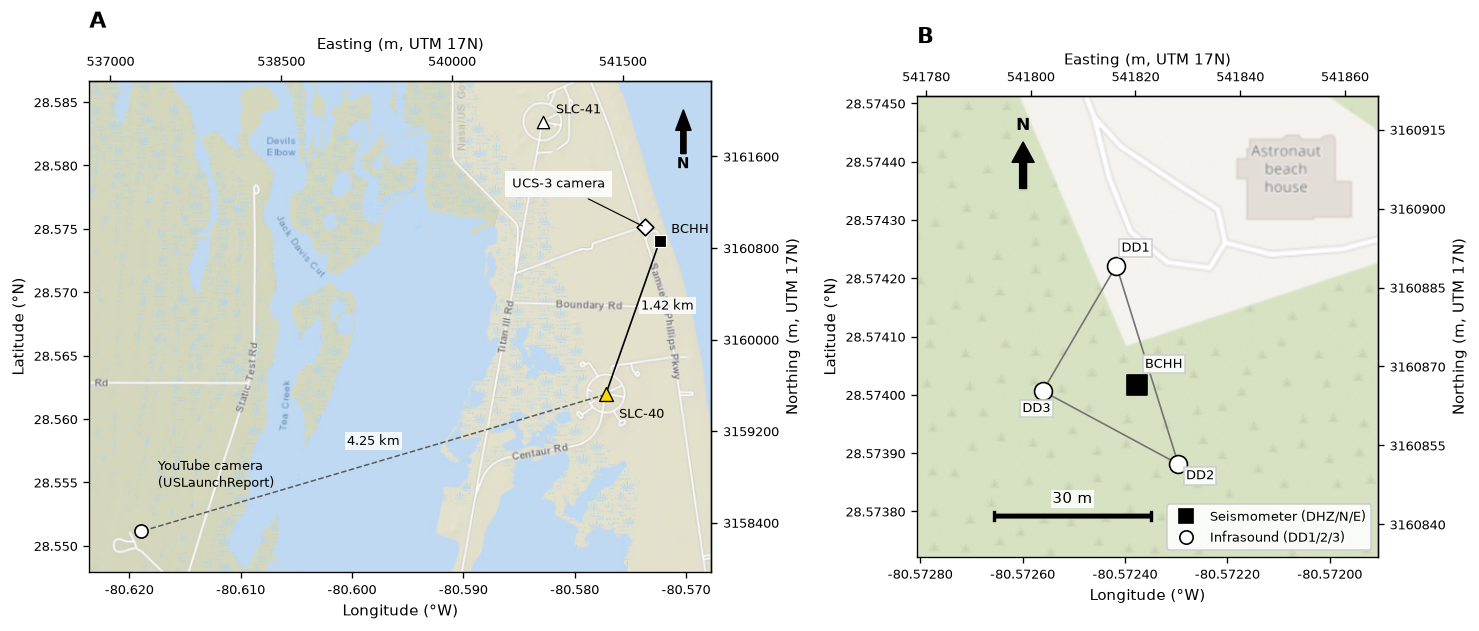

Panel A basemap rendered: True
Panel B basemap: /Users/thompsong/Developer/KSCRocketSeismology/08_falcon9_fireball_paper/notebooks/figure1_panelB_osm_basemap.png
Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/fig01_slc40_bchh_location.pdf
Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/fig01_slc40_bchh_location.png


In [8]:
if RUN_FIGURE1:
    # Updated Figure 1 generation: camera-inclusive Panel A with lat/lon primary
    # axes and secondary UTM labels, plus the improved static-basemap Panel B.


    # Camera placemark used in the expanded Panel A.
    FIGURE1_CAMERA_KML_NAME = next(
        (
            name
            for name in ("FIREY", "YouTube Video")
            if name in figure1_kml_points
        ),
        None,
    )
    if FIGURE1_CAMERA_KML_NAME is None:
        raise KeyError(
            "Could not find the USLaunchReport camera placemark in the Figure 1 KML. "
            "Expected 'FIREY' or 'YouTube Video'."
        )

    FIGURE1_CAMERA = figure1_kml_points[FIGURE1_CAMERA_KML_NAME]
    if "UCS-3" not in figure1_kml_points:
        raise KeyError("UCS-3 coordinates are required in config.KML_FILE; do not infer them from BCHH.")
    FIGURE1_UCS3 = figure1_kml_points["UCS-3"]
    UCS3_LL = (float(FIGURE1_UCS3["lon"]), float(FIGURE1_UCS3["lat"]))

    def _figure1_point_xy(point):
        return FIGURE1_LL_TO_UTM.transform(
            float(point["lon"]),
            float(point["lat"]),
        )

    FIGURE1_SLC40_XY = _figure1_point_xy(FIGURE1_SLC40)
    FIGURE1_SLC41_XY = _figure1_point_xy(FIGURE1_SLC41)
    FIGURE1_CAMERA_XY = _figure1_point_xy(FIGURE1_CAMERA)
    FIGURE1_BCHH_XY = FIGURE1_LL_TO_UTM.transform(
        float(FIGURE1_BCHH["lon"]),
        float(FIGURE1_BCHH["lat"]),
    )

    _, _, FIGURE1_BCHH_DISTANCE_M = FIGURE1_GEOD.inv(
        float(FIGURE1_SLC40["lon"]),
        float(FIGURE1_SLC40["lat"]),
        float(FIGURE1_BCHH["lon"]),
        float(FIGURE1_BCHH["lat"]),
    )
    _, _, FIGURE1_CAMERA_DISTANCE_M = FIGURE1_GEOD.inv(
        float(FIGURE1_SLC40["lon"]),
        float(FIGURE1_SLC40["lat"]),
        float(FIGURE1_CAMERA["lon"]),
        float(FIGURE1_CAMERA["lat"]),
    )


    # Static Panel B basemap extracted from the older good Figure 1 PDF.
    FIGURE1_PANEL_B_BASEMAP_SHA256 = "f7bb29a159896b4a87e097114e1e9a09945d6ccfcf17266d0e339e1b2e4d0e83"

    fig, (ax_a, ax_b) = plt.subplots(
        1, 2,
        figsize=(11.8, 5.5),
        gridspec_kw={"width_ratios": [1.35, 1.0]},
    )

    # =========================================================================
    # PANEL A — camera-inclusive geometry in longitude/latitude
    # =========================================================================

    # Geographic coordinates.
    SLC40_LL = (float(FIGURE1_SLC40["lon"]), float(FIGURE1_SLC40["lat"]))
    SLC41_LL = (float(FIGURE1_SLC41["lon"]), float(FIGURE1_SLC41["lat"]))
    BCHH_LL = (float(FIGURE1_BCHH["lon"]), float(FIGURE1_BCHH["lat"]))
    CAMERA_LL = (float(FIGURE1_CAMERA["lon"]), float(FIGURE1_CAMERA["lat"]))

    def padded_lonlat_limits(points_ll, pad_fraction=0.10):
        lons = np.array([p[0] for p in points_ll], dtype=float)
        lats = np.array([p[1] for p in points_ll], dtype=float)
        dlon = max(lons.max() - lons.min(), 1e-6)
        dlat = max(lats.max() - lats.min(), 1e-6)
        return (
            (lons.min() - pad_fraction * dlon, lons.max() + pad_fraction * dlon),
            (lats.min() - pad_fraction * dlat, lats.max() + pad_fraction * dlat),
        )

    regional_points_ll = [SLC40_LL, SLC41_LL, BCHH_LL, CAMERA_LL, UCS3_LL]
    panel_a_lonlim, panel_a_latlim = padded_lonlat_limits(
        regional_points_ll,
        pad_fraction=0.10,
    )

    ax_a.set_xlim(panel_a_lonlim)
    ax_a.set_ylim(panel_a_latlim)

    panel_a_basemap_ok = False
    if HAVE_CONTEXTILY:
        try:
            ctx.add_basemap(
                ax_a,
                crs="EPSG:4326",
                source=ctx.providers.Esri.WorldStreetMap,
                attribution=False,
                reset_extent=False,
                zoom="auto",
            )
            panel_a_basemap_ok = True
        except Exception as exc:
            warnings.warn(f"Panel A basemap unavailable: {exc}")

    # Reapply exact limits after adding tiles.
    ax_a.set_xlim(panel_a_lonlim)
    ax_a.set_ylim(panel_a_latlim)

    # Propagation paths.
    ax_a.plot(
        [SLC40_LL[0], BCHH_LL[0]],
        [SLC40_LL[1], BCHH_LL[1]],
        color="black",
        linewidth=1.0,
        zorder=4,
    )
    ax_a.plot(
        [SLC40_LL[0], CAMERA_LL[0]],
        [SLC40_LL[1], CAMERA_LL[1]],
        color="0.35",
        linewidth=0.9,
        linestyle="--",
        zorder=4,
    )

    # Locations.
    ax_a.scatter(
        *SLC40_LL,
        marker="^",
        s=70,
        facecolor="gold",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )
    ax_a.scatter(
        *SLC41_LL,
        marker="^",
        s=55,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
        zorder=6,
    )
    ax_a.scatter(
        *BCHH_LL,
        marker="s",
        s=58,
        facecolor="black",
        edgecolor="white",
        linewidth=0.7,
        zorder=7,
    )
    ax_a.scatter(
        *CAMERA_LL,
        marker="o",
        s=62,
        facecolor="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=7,
    )

    ax_a.scatter(*UCS3_LL, marker="D", s=50, facecolor="white",
                 edgecolor="black", zorder=9)
    ax_a.annotate("UCS-3 camera", UCS3_LL, xytext=(-80, 24),
                  textcoords="offset points", fontsize=8, ha="left",
                  arrowprops=dict(arrowstyle="-", lw=0.7), zorder=10,
                  bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    # Labels.
    ax_a.annotate(
        "SLC-40",
        SLC40_LL,
        xytext=(8, -14),
        textcoords="offset points",
        fontsize=8,
        zorder=8,
    )
    ax_a.annotate(
        "SLC-41",
        SLC41_LL,
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=8,
    )
    ax_a.annotate(
        "BCHH",
        BCHH_LL,
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=8,
    )

    # Move camera label up/right so it no longer sits on the dashed path.
    ax_a.annotate(
        "YouTube camera\n(USLaunchReport)",
        CAMERA_LL,
        xytext=(10, 24),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
        zorder=8,
    )

    # Distance labels.
    bmid = (
        0.5 * (SLC40_LL[0] + BCHH_LL[0]),
        0.5 * (SLC40_LL[1] + BCHH_LL[1]),
    )
    cmid = (
        0.5 * (SLC40_LL[0] + CAMERA_LL[0]),
        0.5 * (SLC40_LL[1] + CAMERA_LL[1]),
    )

    ax_a.annotate(
        f"{FIGURE1_BCHH_DISTANCE_M/1000:.2f} km",
        bmid,
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7.5,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=1.0,
        ),
    )

    # Move 4.25-km label above the dashed line and toward its centre.
    ax_a.annotate(
        f"{FIGURE1_CAMERA_DISTANCE_M/1000:.2f} km",
        cmid,
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7.5,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=1.0,
        ),
    )

    ax_a.set_xlabel("Longitude (°W)")
    ax_a.set_ylabel("Latitude (°N)")
    ax_a.set_title("A", loc="left", fontsize=13, fontweight="bold")

    # Add UTM easting/northing as secondary axes, matching Panel B.
    setup_dual_axes(
        ax=ax_a,
        lonlim=panel_a_lonlim,
        latlim=panel_a_latlim,
        ll_to_utm=FIGURE1_LL_TO_UTM,
        utm_to_ll=FIGURE1_UTM_TO_LL,
        lonfmt="%.3f",
        latfmt="%.3f",
        top_nbins=5,
        right_nbins=6,
    )

    # Match ground distances reasonably in geographic coordinates.
    set_equal_ground_aspect(ax_a)

    ax_a.annotate(
        "N",
        xy=(0.955, 0.94),
        xycoords="axes fraction",
        xytext=(0.955, 0.83),
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        arrowprops=dict(facecolor="black", width=3, headwidth=9),
        zorder=20,
    )

    # =========================================================================
    # PANEL B — ORIGINAL WORKING IMPLEMENTATION FROM figure1_utils_fixed.py
    # =========================================================================

    ax = ax_b
    ax.set_title("B", loc="left", fontsize=13, fontweight="bold")

    center_lon = FIGURE1_BCHH["lon"] + 0.00002
    center_lat = FIGURE1_BCHH["lat"] + 0.00010

    lonlim, latlim = equal_scale_lonlat_limits(
        center_lon,
        center_lat,
        width_lon=0.00090,
    )

    setup_dual_axes(
        ax=ax,
        lonlim=lonlim,
        latlim=latlim,
        ll_to_utm=FIGURE1_LL_TO_UTM,
        utm_to_ll=FIGURE1_UTM_TO_LL,
        lonfmt="%.5f",
        latfmt="%.5f",
        top_nbins=5,
        right_nbins=6,
    )

    set_equal_ground_aspect(ax)

    # Use the exact raster embedded in the older good Figure 1 PDF.
    # This avoids all live OSM/Esri tile-server dependencies.
    if not FIGURE1_PANEL_B_BASEMAP_FILE.is_file():
        raise FileNotFoundError(
            f"Static Panel B basemap not found: {FIGURE1_PANEL_B_BASEMAP_FILE}"
        )

    import hashlib
    panel_b_sha256 = hashlib.sha256(
        FIGURE1_PANEL_B_BASEMAP_FILE.read_bytes()
    ).hexdigest()

    if panel_b_sha256 != FIGURE1_PANEL_B_BASEMAP_SHA256:
        warnings.warn(
            "Panel B basemap checksum differs from the known extracted asset. "
            f"Expected {FIGURE1_PANEL_B_BASEMAP_SHA256}, got {panel_b_sha256}"
        )

    panel_b_image = plt.imread(FIGURE1_PANEL_B_BASEMAP_FILE)

    # The image in the old PDF is the basemap itself, generated for these exact
    # geographic limits. Draw it beneath all current vector geometry.
    ax.imshow(
        panel_b_image,
        extent=[lonlim[0], lonlim[1], latlim[0], latlim[1]],
        origin="upper",
        interpolation="bilinear",
        aspect="auto",
        zorder=0,
    )

    # Restore exact limits/aspect after imshow.
    ax.set_xlim(lonlim)
    ax.set_ylim(latlim)
    set_equal_ground_aspect(ax)

    # Infrasound triangle.
    infrasound = FIGURE1_BCHH_SENSORS[
        FIGURE1_BCHH_SENSORS["sensor"].str.startswith("HD")
    ]
    triangle = (
        infrasound.set_index("sensor")
        .loc[["HD1", "HD2", "HD3", "HD1"]]
    )

    ax.plot(
        triangle["lon"],
        triangle["lat"],
        color="0.45",
        lw=1.0,
        zorder=10,
    )

    # Sensors.
    for row in FIGURE1_BCHH_SENSORS.itertuples(index=False):
        if row.sensor == "Seismometer":
            ax.scatter(
                row.lon,
                row.lat,
                marker="s",
                s=145,
                c="black",
                edgecolor="black",
                zorder=20,
            )
        else:
            ax.scatter(
                row.lon,
                row.lat,
                marker="o",
                s=115,
                c="white",
                edgecolor="black",
                zorder=20,
            )

    label_offsets = {
        "HD1": (0.00001, 0.00003),
        "HD2": (0.000015, -0.00002),
        "HD3": (-0.00004, -0.00003),
        "Seismometer": (0.000015, 0.000035),
    }

    for row in FIGURE1_BCHH_SENSORS.itertuples(index=False):
        dx, dy = label_offsets[row.sensor]
        add_label(
            ax,
            row.lon,
            row.lat,
            row.label,
            dx=dx,
            dy=dy,
            size=8,
        )

    add_scalebar_lonlat(
        ax=ax,
        lon=lonlim[0] + 0.00015,
        lat=latlim[0] + 0.00007,
        length_m=30,
        label_text="30 m",
        geod=FIGURE1_GEOD,
    )

    add_north_arrow_axes(
        ax,
        xy=(0.23, 0.80),
        length=0.10,
    )

    legend_handles = [
        plt.Line2D(
            [],
            [],
            marker="s",
            ls="",
            ms=8,
            mfc="black",
            mec="black",
            label="Seismometer (DHZ/N/E)",
        ),
        plt.Line2D(
            [],
            [],
            marker="o",
            ls="",
            ms=8,
            mfc="white",
            mec="black",
            label="Infrasound (DD1/2/3)",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="lower right",
        fontsize=8,
        framealpha=0.9,
    )

    fig.subplots_adjust(
        left=0.065,
        right=0.975,
        bottom=0.105,
        top=0.89,
        wspace=0.38,
    )

    outfile_pdf = OUTDIR / "fig01_slc40_bchh_location.pdf"
    outfile_png = OUTDIR / "fig01_slc40_bchh_location.png"

    fig.savefig(
        outfile_pdf,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    fig.savefig(
        outfile_png,
        dpi=180,
        bbox_inches="tight",
        pad_inches=0.05,
    )

    plt.show()

    print("Panel A basemap rendered:", panel_a_basemap_ok)
    print("Panel B basemap:", FIGURE1_PANEL_B_BASEMAP_FILE)
    print("Saved:", outfile_pdf)
    print("Saved:", outfile_png)

    fig1 = fig
    fig1_axes = (ax_a, ax_b)

In [9]:
if RUN_FIGURE1:

    figure1_output_paths = save_figure(
        fig=fig1,
        output_directory=OUTDIR,
        filename_stem=FIGURE1_STEM,
        extensions=("pdf",),
        dpi=300,
    )

    for path in figure1_output_paths:
        print(path.resolve())

/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/fig01_slc40_bchh_location.pdf


## 3. Receiver-specific acoustic propagation

BCHH geometry and the adopted effective acoustic speed come directly from
Notebooks 02, 03, and 08. Camera distances are computed from the canonical
SLC-40 coordinate and KML camera coordinates.


In [10]:
# BCHH propagation uses the meteorological path-effective speed from Notebook 020.
bchh_channels_df["effective_sound_speed_mps"] = ADOPTED_ACOUSTIC_SPEED_MPS
bchh_channels_df["acoustic_travel_time_s"] = (
    bchh_channels_df["distance_m"] / ADOPTED_ACOUSTIC_SPEED_MPS
)
bchh_channels_df["shockwave_travel_time_s"] = (
    bchh_channels_df["acoustic_travel_time_s"]
)

# Camera paths have different azimuths and therefore different wind projections.
if not camera_locations_df.empty:
    camera_locations_df["wind_along_ray_mps"] = (
        WindSpeedMps
        * np.cos(
            np.deg2rad(
                camera_locations_df["ray_azimuth_deg"] - WindDirectionToDeg
            )
        )
    )
    camera_locations_df["effective_sound_speed_mps"] = (
        STILL_AIR_SOUND_SPEED_MPS
        + camera_locations_df["wind_along_ray_mps"]
    )
    camera_locations_df["acoustic_travel_time_s"] = (
        camera_locations_df["distance_m"]
        / camera_locations_df["effective_sound_speed_mps"]
    )
    camera_locations_df["shockwave_travel_time_s"] = (
        camera_locations_df["acoustic_travel_time_s"]
    )

SENSOR_ACOUSTIC_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("channel")["acoustic_travel_time_s"]
    .to_dict()
)
SENSOR_SHOCKWAVE_TRAVEL_TIMES_S = dict(SENSOR_ACOUSTIC_TRAVEL_TIMES_S)
CAMERA_DISTANCES_M = (
    camera_locations_df.set_index("camera_id")["distance_m"].to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_EFFECTIVE_SPEEDS_MPS = (
    camera_locations_df
    .set_index("camera_id")["effective_sound_speed_mps"]
    .to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_ACOUSTIC_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["acoustic_travel_time_s"]
    .to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_SHOCKWAVE_TRAVEL_TIMES_S = dict(CAMERA_ACOUSTIC_TRAVEL_TIMES_S)

ACOUSTIC_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS
WIND_SPEED_MPS = WindSpeedMps
SHOCK_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS

display(bchh_channels_df[[
    "channel",
    "distance_m",
    "back_azimuth_to_slc40_deg",
    "effective_sound_speed_mps",
    "acoustic_travel_time_s",
]])
if not camera_locations_df.empty:
    display(camera_locations_df[[
        "camera_id",
        "name",
        "distance_m",
        "ray_azimuth_deg",
        "wind_along_ray_mps",
        "effective_sound_speed_mps",
        "acoustic_travel_time_s",
    ]])

,channel,distance_m,back_azimuth_to_slc40_deg,effective_sound_speed_mps,acoustic_travel_time_s
0,DD1,1439.963831,198.988027,351.0,4.102461
1,DD2,1408.338457,199.943252,351.0,4.012360
2,DD3,1412.854330,198.763913,351.0,4.025226
3,DHE,1419.886511,199.438026,351.0,4.045261
4,DHN,1419.886511,199.438026,351.0,4.045261
5,DHZ,1419.886511,199.438026,351.0,4.045261


,camera_id,name,distance_m,ray_azimuth_deg,wind_along_ray_mps,effective_sound_speed_mps,acoustic_travel_time_s
0,youtube,FIREY,4254.532067,253.676701,1.471983,349.801563,12.162702
1,pad_nw,PadNW,102.864227,319.923729,4.549156,352.878735,0.291500
2,pad_west,PadW,134.745638,280.624512,3.270974,351.600553,0.383235
3,pad_ne,PadNE,70.670423,44.172628,0.847620,349.177200,0.202391
4,ucs3,UCS-3,1501.050255,13.445065,3.021181,351.350760,4.272227


## 4. Load the canonical Notebook 010 waveform product

The figure notebook uses the response-corrected Stream with the adopted
moving-median correction already applied to DD1–DD3. Seismic D* channels are
unchanged by that correction.


In [11]:
st_corr = read(
    str(BASELINE_STREAM_FILE),
    format="PICKLE",
)
st_corr.trim(
    EXPLOSION_TIME - PRE_EVENT_SEC,
    EXPLOSION_TIME + POST_EVENT_SEC,
    pad=False,
)
st_corr.sort(keys=["station", "channel"])

loaded_channels = {
    trace.stats.channel
    for trace in st_corr
}
missing_channels = set(CHANNEL_ORDER) - loaded_channels
if missing_channels:
    raise KeyError(
        f"Notebook 010 baseline Stream lacks channels: {sorted(missing_channels)}"
    )

print(f"Loaded canonical waveform product:\n  {BASELINE_STREAM_FILE}")
print(st_corr)
for trace in st_corr:
    print(
        trace.id,
        trace.stats.starttime,
        trace.stats.endtime,
        trace.stats.sampling_rate,
        trace.stats.npts,
        trace.stats.get("units", "units not stored"),
    )

if CORRECTION_SUMMARY_FILE.exists():
    correction_summary_df = pd.read_csv(CORRECTION_SUMMARY_FILE)
    display(correction_summary_df)
else:
    correction_summary_df = None

Loaded canonical waveform product:
  /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD1 2016-09-01T13:04:11.912000Z 2016-09-01T13:37:11.912000Z 250.0 495001 Pa
1R.BCHH.10.

,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,371941.437729,495001,495001,-253.017928,1349.141535,1349.141535,5.801766e-03,-4.133078e-01,33.066224,33.066224
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,1723.124206,495001,495001,-219.103740,1557.411623,1557.411623,4.222571e-03,-4.249353e-02,7.850754,7.850755
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,21436.756106,495001,495001,-222.554283,1434.860908,1434.860908,2.308773e-03,1.220004e+00,13.326344,13.326344
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,4292.747539,495001,495001,-0.001094,0.001004,0.001094,1.711102e-12,-1.149445e-09,0.000013,0.000013
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,6546.845941,495001,495001,-0.002207,0.001867,0.002207,-3.954770e-12,-2.978695e-11,0.000022,0.000022
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,13988.740200,495001,495001,-0.002876,0.002173,0.002876,-2.641120e-14,-2.085258e-09,0.000033,0.000033


## 5. Channel-type helpers

Instrument-response removal has already been completed. These helpers are retained only because the plotting and display-preprocessing functions use them to apply channel-specific filters and labels.


In [12]:
def is_seismic_channel(channel: str) -> bool:
    """Return True for the BCHH high-gain seismic channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] in {"H", "L"}


def is_infrasound_channel(channel: str) -> bool:
    """Return True for the BCHH pressure channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] == "D"


def is_audio_channel(channel: str) -> bool:
    """Return True for imported video/audio waveform channels."""
    return channel.upper() in {"AUD", "AUDIO"}

## 6. Generic plotting and preprocessing utilities

Zero-phase filtering can introduce acausal ringing and apparent pre-onset energy; causal filtering has frequency-dependent delay. Timing should be checked against minimally processed traces, and display-filtered traces must not establish direct-wave onset.


In [13]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime | None = None,
    endtime: UTCDateTime | None = None,
    infra_filter: dict | None = None,
    seis_filter: dict | None = None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        if starttime is not None and endtime is not None:
            tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(
    channel: str,
    distance_m: float,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
) -> float:
    """Return the travel-time correction for one physical BCHH channel."""
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time_physical(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
    audio_delay_s: float,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time."""
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                distance_m=sensor_distances_m[ch],
                acoustic_speed_mps=acoustic_speed_mps,
                direct_seismic_speed_mps=direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


def zerophase_tag(zerophase: bool) -> str:
    """Short filename tag for the filter phase convention."""
    return "zp_true" if bool(zerophase) else "zp_false"


def add_zerophase_tag(outfile_base: Path, zerophase: bool) -> Path:
    """Append the zerophase convention to an output filename stem."""
    return outfile_base.with_name(f"{outfile_base.name}_{zerophase_tag(zerophase)}")


def bandpass_filter_dict(freqmin, freqmax, corners=4, zerophase=False):
    """Build an ObsPy bandpass filter dictionary with explicit zerophase."""
    return {
        "type": "bandpass",
        "freqmin": float(freqmin),
        "freqmax": float(freqmax),
        "corners": int(corners),
        "zerophase": bool(zerophase),
    }

## 7. Build the response-corrected display stream


In [14]:
def build_overview_stream(
    st: Stream,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.5,
    infra_freqmax: float = 25.0,
    seis_freqmin: float = 0.5,
    seis_freqmax: float = 25.0,
    corners: int = 4,
) -> Stream:
    """Build the filtered 30-minute display stream for one zerophase setting."""
    overview_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    overview_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    return preprocess_display_stream(
        st,
        starttime=plot_start,
        endtime=plot_end,
        infra_filter=overview_infra_filter,
        seis_filter=overview_seis_filter,
    )


st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = build_overview_stream(
    st=st_ordered,
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    zerophase=ZEROPHASE,
)

print(f"Overview stream built with ZEROPHASE={ZEROPHASE}")
print(st_overview)

Overview stream built with ZEROPHASE=True
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples


## 8. Figure 2: 30-minute overview figure


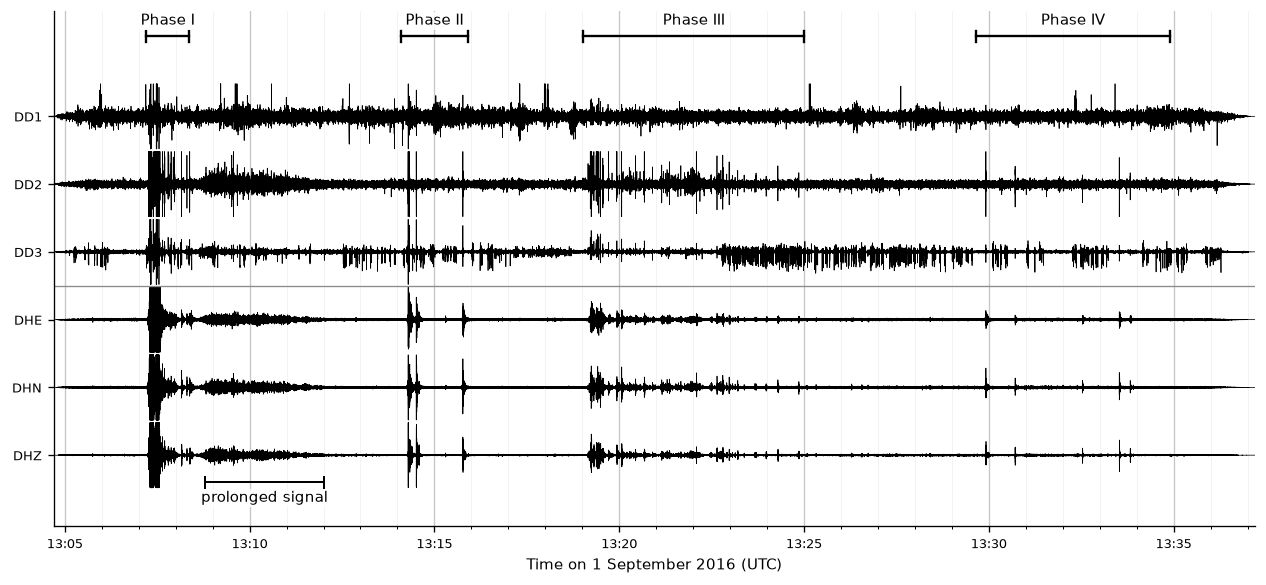

In [15]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    prolonged_signal_start: UTCDateTime | None = None,
    prolonged_signal_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if prolonged_signal_start is not None and prolonged_signal_end is not None:
        if prolonged_signal_end >= plot_start and prolonged_signal_start <= plot_end:
            add_time_bar(
                ax,
                max(prolonged_signal_start, plot_start),
                min(prolonged_signal_end, plot_end),
                y=-0.4,
                text='prolonged signal',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    fig.savefig(outfile_base.with_suffix('.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


overview_outfile = add_zerophase_tag(
    OUTDIR / 'fig03_bchh_30min_overview',
    ZEROPHASE,
)

fig, ax = make_overview_figure(
    st_overview,
    overview_outfile,
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    prolonged_signal_start=PROLONGED_SIGNAL_START,
    prolonged_signal_end=PROLONGED_SIGNAL_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()

## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [16]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)

,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,1R.BCHH.10.DD1,DD1,Pa,250.0,-138.805934,1301.957262,29.460085,83.425475
1,1R.BCHH.10.DD2,DD2,Pa,250.0,-163.344631,1507.523187,6.779089,35.129625
2,1R.BCHH.10.DD3,DD3,Pa,250.0,-163.765403,1385.597666,32.291717,57.071517
3,1R.BCHH.10.DHE,DHE,m/s,250.0,-0.001094,0.001004,0.000033,0.000188
4,1R.BCHH.10.DHN,DHN,m/s,250.0,-0.002207,0.001867,0.000043,0.000295
5,1R.BCHH.10.DHZ,DHZ,m/s,250.0,-0.002876,0.002173,0.000057,0.000476


## Peak and reduced-pressure measurements from Notebook 080

The authoritative numerical measurements are loaded from
`key_event_pressure_measurements.csv`. This notebook only displays them and
uses the corresponding pipeline event times to define waveform panels.


In [17]:
from collections.abc import Mapping

# Surveyed source-to-sensor distances from SLC-40.
# Update these values if the final geometry table changes.
BCHH_INFRASOUND_DISTANCES_M = {
    "DD1": 1442.2,
    "DD2": 1410.2,
    "DD3": 1414.8,
}


def _channel_code(trace) -> str:
    """Return the final channel code, e.g. DD1, from an ObsPy Trace."""
    return str(trace.stats.channel).upper()


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    #highpass: bool = False,
) -> pd.DataFrame:
    """
    Measure observed and reduced pressures from a short calibrated event stream.

    Parameters
    ----------
    st_event
        ObsPy Stream containing calibrated infrasound traces in Pa. The stream
        should already be trimmed to the desired event window.
    sensor_distances_m
        Mapping from channel code, such as ``DD1``, to source-to-sensor
        distance in metres.
    reference_distance_m
        Distance to which pressures are reduced. The default is 1000 m.
    event_name
        Optional event label added to the output table.

    Returns
    -------
    pandas.DataFrame
        One row per infrasound channel, containing observed and reduced
        positive, negative, negative-magnitude, and peak-to-peak pressures.

    Notes
    -----
    Reduced pressure is calculated assuming spherical spreading:

        p_reduced = p_observed * distance / reference_distance

    The negative pressure retains its sign. ``negative_magnitude_pa`` is also
    included for convenient comparison with the positive peak.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if len(st_event) == 0:
        raise ValueError("st_event contains no traces.")

    rows: list[dict[str, Any]] = []
    
    st_event2 = st_event.copy()
    #if highpass:
    #    st_event2.filter('highpass', freq=5, corners=2)
    for tr in st_event2:
        channel = _channel_code(tr)

        if channel not in sensor_distances_m:
            continue

        distance_m = float(sensor_distances_m[channel])
        if not np.isfinite(distance_m) or distance_m <= 0:
            raise ValueError(
                f"Invalid source distance for {channel}: {distance_m}"
            )

        data = np.asarray(tr.data, dtype=float)
        data = data[np.isfinite(data)]

        if data.size == 0:
            raise ValueError(f"{tr.id} contains no finite samples.")

        positive_peak_pa = float(np.max(data))
        negative_peak_pa = float(np.min(data))
        negative_magnitude_pa = abs(negative_peak_pa)
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "starttime": tr.stats.starttime,
                "endtime": tr.stats.endtime,
                "sampling_rate_hz": float(tr.stats.sampling_rate),
                "npts": int(tr.stats.npts),
                "distance_m": distance_m,
                "reference_distance_m": float(reference_distance_m),
                "reduction_factor": reduction_factor,
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "negative_magnitude_pa": negative_magnitude_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "negative_magnitude_reduced_pa": (
                    negative_magnitude_pa * reduction_factor
                ),
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        available = sorted({_channel_code(tr) for tr in st_event})
        expected = sorted(sensor_distances_m)
        raise ValueError(
            "No traces matched the distance dictionary. "
            f"Available channels: {available}; expected channels: {expected}"
        )

    result = pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)

    # Add robust three-sensor summaries as a separate final row.
    numeric_columns = [
        "distance_m",
        "reduction_factor",
        "positive_peak_pa",
        "negative_peak_pa",
        "negative_magnitude_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_peak_pa",
        "negative_reduced_pa",
        "negative_magnitude_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "starttime": result["starttime"].min(),
        "endtime": result["endtime"].max(),
        "sampling_rate_hz": result["sampling_rate_hz"].median(),
        "npts": np.nan,
        "reference_distance_m": float(reference_distance_m),
    }

    for column in dict.fromkeys(numeric_columns):
        summary[column] = result[column].median()

    result = pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

    return result


def measure_reduced_pressures_in_window(
    st: Stream,
    starttime: UTCDateTime | str,
    endtime: UTCDateTime | str,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    nearest_sample: bool = True,
    #highpass: bool = False,
) -> tuple[Stream, pd.DataFrame]:
    """
    Trim a calibrated stream to an event window and measure reduced pressures.

    Returns both the trimmed event stream and the measurement table.
    """
    t0 = UTCDateTime(starttime)
    t1 = UTCDateTime(endtime)

    if t1 <= t0:
        raise ValueError(f"endtime must follow starttime: {t0} to {t1}")

    st_event = st.copy()
    st_event.trim(
        starttime=t0,
        endtime=t1,
        nearest_sample=nearest_sample,
        pad=False,
    )

    '''
    # Retain only infrasound channels represented in the distance dictionary.
    st_event = Stream(
        traces=[
            tr for tr in st_event
            if _channel_code(tr) in sensor_distances_m
        ]
    )
    '''

    measurements = measure_reduced_pressures(
        Stream(tr for tr in st_event if _channel_code(tr) in sensor_distances_m),
        sensor_distances_m,
        reference_distance_m=reference_distance_m,
        event_name=event_name,
        #highpass=highpass,
    )

    return st_event, measurements


def pressure_results_for_paper(
    measurements: pd.DataFrame,
) -> pd.DataFrame:
    """Return a compact, publication-oriented view of the measurements."""
    columns = [
        "event",
        "channel",
        "distance_m",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output = measurements.loc[:, columns].copy()

    pressure_columns = [
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output["distance_m"] = output["distance_m"].round(1)
    output[pressure_columns] = output[pressure_columns].round(1)

    return output

In [18]:
print(st_corr)

6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:11.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 495001 samples


In [19]:
if key_event_pressures.empty:
    warnings.warn(
        f"Notebook 080 pressure measurements not found: "
        f"{KEY_EVENT_PRESSURES_FILE}"
    )
else:
    print("Authoritative Notebook 080 key-event measurements:")
    display(key_event_pressures)

if key_event_windows.empty:
    warnings.warn(
        f"Notebook 080 measurement windows not found: "
        f"{KEY_EVENT_WINDOWS_FILE}"
    )
else:
    print("Authoritative Notebook 080 measurement windows:")
    display(key_event_windows)

Authoritative Notebook 080 key-event measurements:


,event,id,channel,distance_m,baseline_pa,positive_peak_time_s,negative_peak_time_s,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_reduced_pa,negative_reduced_pa,peak_to_peak_reduced_pa
0,Initial second-stage failure,1R.BCHH.10.DD1,DD1,1439.963831,9.656473,1.016,0.860,30.387534,-72.234299,102.621833,43.756950,-104.014777,147.771727
1,Initial second-stage failure,1R.BCHH.10.DD2,DD2,1408.338457,0.198394,0.928,1.176,51.644344,-25.465453,77.109797,72.732715,-35.863977,108.596692
2,Initial second-stage failure,1R.BCHH.10.DD3,DD3,1412.854330,0.034235,1.292,1.188,38.837744,-21.239290,60.077033,54.872075,-30.008022,84.880097
3,Initial second-stage failure,ARRAY_MEDIAN,MEDIAN,1412.854330,0.198394,NaN,NaN,38.837744,-25.465453,77.109797,54.872075,-35.863977,108.596692
4,Principal explosion,1R.BCHH.10.DD1,DD1,1439.963831,-10.140813,1.556,1.992,1312.098076,-127.823477,1439.921553,1889.373771,-184.061184,2073.434955
5,Principal explosion,1R.BCHH.10.DD2,DD2,1408.338457,-7.748999,1.468,1.780,1515.272186,-155.595632,1670.867818,2134.016092,-219.131312,2353.147404
6,Principal explosion,1R.BCHH.10.DD3,DD3,1412.854330,-8.503335,1.480,1.920,1394.101001,-155.262068,1549.363069,1969.661636,-219.362685,2189.024321
7,Principal explosion,ARRAY_MEDIAN,MEDIAN,1412.854330,-8.503335,NaN,NaN,1394.101001,-155.262068,1549.363069,1969.661636,-219.131312,2189.024321
8,Payload impact,1R.BCHH.10.DD1,DD1,1439.963831,19.310221,0.224,0.268,229.864787,-123.976665,353.841452,330.996979,-178.521914,509.518892
9,Payload impact,1R.BCHH.10.DD2,DD2,1408.338457,-3.182755,0.136,0.180,279.145109,-115.324633,394.469742,393.130792,-162.416116,555.546908


Authoritative Notebook 080 measurement windows:


,event,source_event_key,legacy_351mps_source_time_utc,legacy_351mps_source_time_epoch_s,arrival_reference_channel,arrival_reference_distance_m,legacy_source_reduction_speed_mps,legacy_351mps_reference_travel_time_s,reference_arrival_utc,reference_arrival_basis,...,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,pressure_reduction_reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:15.927934,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:19.427235,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.407995,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.45,0.0,0.07,0.08,0.45,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.987823,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...


In [20]:

from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from obspy import Stream, UTCDateTime


def plot_main_explosion(
    st_event: Stream,
    *,
    reference_time: UTCDateTime | str,
    pressure_results=None,
    title: str = "Principal explosion",
    seismic_channels: tuple[str, ...] = ("DHZ", "DHN", "DHE"),
    infrasound_channels: tuple[str, ...] = ("DD1", "DD2", "DD3"),
    seismic_labels: Mapping[str, str] | None = None,
    infrasound_labels: Mapping[str, str] | None = None,
    figsize: tuple[float, float] = (11.5, 6.8),
    outfile=None,
    add_measurements=False,
):
    """
    Plot the principal explosion as grouped seismic and infrasound panels.

    Parameters
    ----------
    st_event
        Response-corrected event stream. Seismic traces must be in m/s and
        infrasound traces in Pa.
    reference_time
        Time used for the relative x-axis.
    pressure_results
        Optional DataFrame returned by the pressure measurement function.
        When supplied, positive and negative pressure extrema are marked.
    title
        Figure title.
    outfile
        Optional output path. If supplied, the figure is saved.
    """
    reference_time = UTCDateTime(reference_time)

    if seismic_labels is None:
        seismic_labels = {
            "DHZ": "Vertical",
            "DHN": "North",
            "DHE": "East",
        }

    if infrasound_labels is None:
        infrasound_labels = {
            "DD1": "DD1",
            "DD2": "DD2",
            "DD3": "DD3",
        }

    seismic_traces = []
    for channel in seismic_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        seismic_traces.append(matches[0])

    pressure_traces = []
    for channel in infrasound_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        pressure_traces.append(matches[0])

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    grid = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )

    seismic_axes = [
        fig.add_subplot(grid[row, 0])
        for row in range(3)
    ]

    pressure_axes = [
        fig.add_subplot(grid[row, 1])
        for row in range(3)
    ]

    # Determine common limits within each instrument group.
    seismic_limit = max(
        np.nanmax(np.abs(np.asarray(tr.data, dtype=float)))
        for tr in seismic_traces
    )
    seismic_limit *= 1.08

    pressure_min = min(
        np.nanmin(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )
    pressure_max = max(
        np.nanmax(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )

    pressure_padding = 0.05 * (pressure_max - pressure_min)
    pressure_ylim = (
        pressure_min - pressure_padding,
        pressure_max + pressure_padding,
    )

    # Plot seismic components.
    for index, (ax, tr) in enumerate(
        zip(seismic_axes, seismic_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=0.9)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)

        ax.set_ylim(-seismic_limit, seismic_limit)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        ax.text(
            0.02,
            0.86,
            seismic_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Plot infrasound channels.
    for index, (ax, tr) in enumerate(
        zip(pressure_axes, pressure_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=1.0)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)
        ax.set_ylim(*pressure_ylim)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.text(
            0.02,
            0.86,
            infrasound_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        # Mark positive and negative extrema.
        positive_index = int(np.nanargmax(data))
        negative_index = int(np.nanargmin(data))

        positive_time = time_s[positive_index]
        negative_time = time_s[negative_index]

        positive_value = data[positive_index]
        negative_value = data[negative_index]

        ax.scatter(
            positive_time,
            positive_value,
            s=24,
            zorder=4,
        )
        ax.scatter(
            negative_time,
            negative_value,
            s=24,
            zorder=4,
        )

        ax.annotate(
            f"{positive_value:.0f} Pa",
            xy=(positive_time, positive_value),
            xytext=(5, -16),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="top",
        )

        ax.annotate(
            f"{negative_value:.0f} Pa",
            xy=(negative_time, negative_value),
            xytext=(5, 7),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Shared x limits.
    all_traces = seismic_traces + pressure_traces

    xmin = min(
        tr.stats.starttime - reference_time
        for tr in all_traces
    )
    xmax = max(
        tr.stats.endtime - reference_time
        for tr in all_traces
    )

    for ax in seismic_axes + pressure_axes:
        ax.set_xlim(xmin, xmax)
        ax.grid(axis="x", linewidth=0.4, alpha=0.3)

    seismic_axes[0].set_title(
        "Ground velocity",
        fontsize=11,
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Acoustic pressure",
        fontsize=11,
        fontweight="bold",
    )

    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel(
        "Pressure (Pa)"
    )

    seismic_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )
    pressure_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
    )

    if pressure_results is not None and add_measurements:
        sensor_rows = pressure_results[
            pressure_results["channel"].isin(infrasound_channels)
        ]

        if len(sensor_rows) > 0:
            median_positive = sensor_rows[
                "positive_peak_pa"
            ].median()

            median_reduced = sensor_rows[
                "positive_reduced_pa"
            ].median()

            fig.text(
                0.995,
                0.91,
                (
                    f"Median positive peak: {median_positive / 1000:.2f} kPa; "
                    f"median reduced pressure at 1 km: "
                    f"{median_reduced / 1000:.2f} kPa"
                ),
                ha="right",
                va="bottom",
                fontsize=8.5,
            )

    if outfile is not None:
        fig.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight",
        )

    return fig, {
        "seismic": seismic_axes,
        "infrasound": pressure_axes,
    }

In [21]:

from collections.abc import Mapping

import numpy as np
import pandas as pd
from obspy import Stream, UTCDateTime


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    baseline_start_s: float = 0.0,
    baseline_end_s: float = 0.75,
    signal_start_s: float | None = None,
    signal_end_s: float | None = None,
) -> pd.DataFrame:
    """
    Measure locally baseline-corrected pressure amplitudes.

    Times are specified in seconds relative to the start of each trace in
    ``st_event``.

    Parameters
    ----------
    st_event
        Calibrated infrasound event stream in Pa.
    sensor_distances_m
        Mapping from channel code to source-to-sensor distance in metres.
    reference_distance_m
        Reference distance for reduced pressure.
    event_name
        Optional event label.
    baseline_start_s, baseline_end_s
        Quiet pre-event interval used to estimate the local pressure baseline.
    signal_start_s, signal_end_s
        Interval over which extrema are measured. If omitted, measurement begins
        at ``baseline_end_s`` and continues to the end of the trace.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if baseline_end_s <= baseline_start_s:
        raise ValueError("baseline_end_s must be greater than baseline_start_s.")

    if signal_start_s is None:
        signal_start_s = baseline_end_s

    rows = []

    for tr in st_event:
        channel = str(tr.stats.channel).upper()

        if channel not in sensor_distances_m:
            continue

        data = np.asarray(tr.data, dtype=float)
        sampling_rate = float(tr.stats.sampling_rate)
        times = tr.times()

        baseline_mask = (
            (times >= baseline_start_s)
            & (times < baseline_end_s)
            & np.isfinite(data)
        )

        if not np.any(baseline_mask):
            raise ValueError(
                f"No baseline samples found for {tr.id} in "
                f"{baseline_start_s:.3f}–{baseline_end_s:.3f} s."
            )

        baseline_pa = float(np.nanmedian(data[baseline_mask]))
        corrected_data = data - baseline_pa

        signal_mask = (
            (times >= signal_start_s)
            & np.isfinite(corrected_data)
        )

        if signal_end_s is not None:
            signal_mask &= times <= signal_end_s

        if not np.any(signal_mask):
            raise ValueError(
                f"No signal samples found for {tr.id} in the requested window."
            )

        signal_data = corrected_data[signal_mask]
        signal_times = times[signal_mask]

        positive_index = int(np.nanargmax(signal_data))
        negative_index = int(np.nanargmin(signal_data))

        positive_peak_pa = float(signal_data[positive_index])
        negative_peak_pa = float(signal_data[negative_index])
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        distance_m = float(sensor_distances_m[channel])
        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "distance_m": distance_m,
                "baseline_pa": baseline_pa,
                "positive_peak_time_s": float(signal_times[positive_index]),
                "negative_peak_time_s": float(signal_times[negative_index]),
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        raise ValueError("No infrasound channels matched sensor_distances_m.")

    result = (
        pd.DataFrame(rows)
        .sort_values("channel")
        .reset_index(drop=True)
    )

    summary_columns = [
        "distance_m",
        "baseline_pa",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "positive_peak_time_s": np.nan,
        "negative_peak_time_s": np.nan,
    }

    for column in summary_columns:
        summary[column] = float(result[column].median())

    return pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

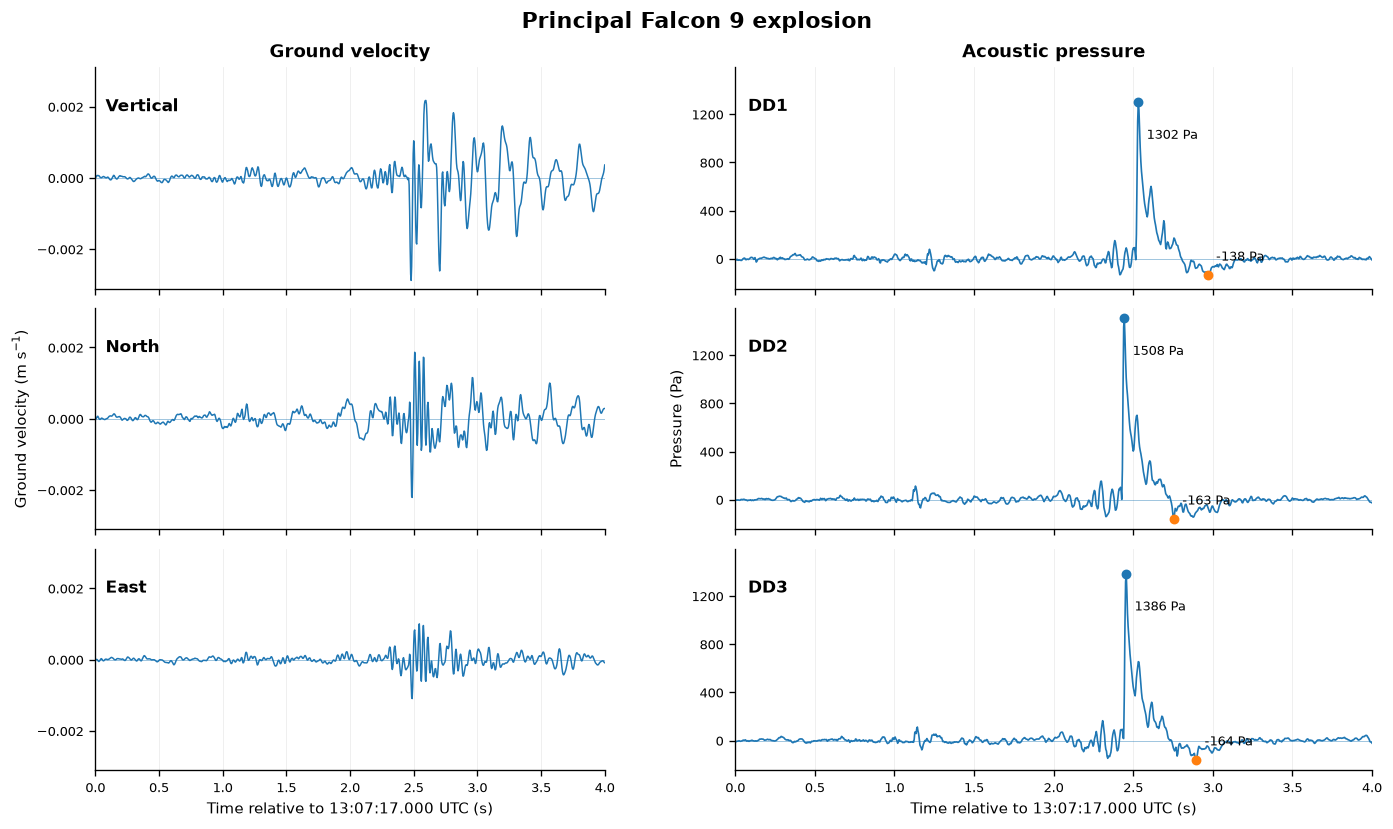

In [22]:
def floor_utc_to_second(value):
    return UTCDateTime(np.floor(float(UTCDateTime(value))))


def ceil_utc_to_second(value):
    return UTCDateTime(np.ceil(float(UTCDateTime(value))))


principal_window = key_event_window(r"principal")

MAIN_EXPLOSION_MEASUREMENT_START = principal_window["start"]
MAIN_EXPLOSION_MEASUREMENT_END = principal_window["end"]
MAIN_EXPLOSION_START = floor_utc_to_second(MAIN_EXPLOSION_MEASUREMENT_START)
MAIN_EXPLOSION_END = ceil_utc_to_second(MAIN_EXPLOSION_MEASUREMENT_END)

st_main_explosion = st_corr.copy().trim(
    MAIN_EXPLOSION_START,
    MAIN_EXPLOSION_END,
)
main_explosion_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("principal", case=False, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_main_explosion,
    reference_time=MAIN_EXPLOSION_START,
    pressure_results=main_explosion_pressures,
    title="Principal Falcon 9 explosion",
    outfile=OUTDIR / "principal_explosion_waveforms.pdf",
)

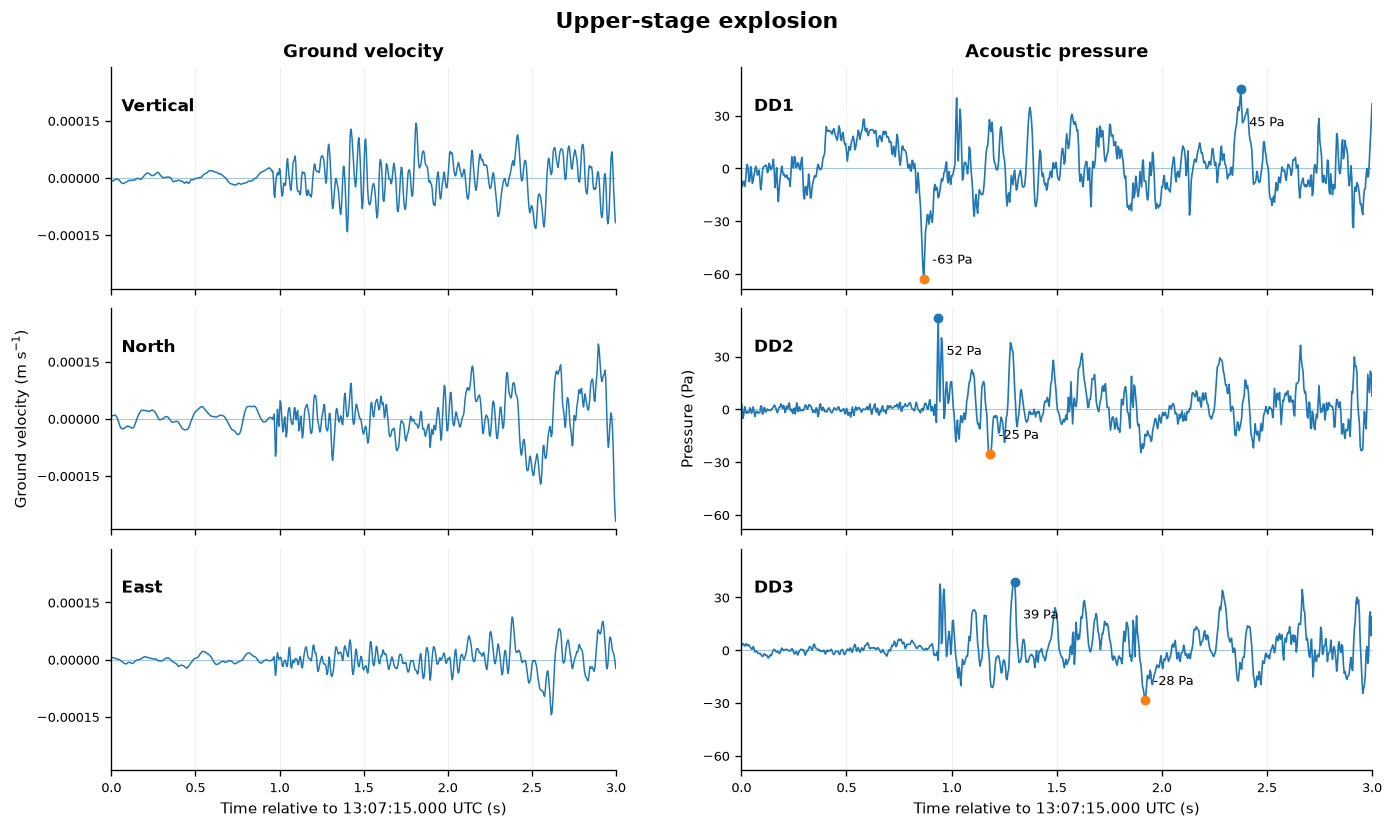

In [23]:
second_stage_window = key_event_window(
    r"upper-stage|upper stage|second-stage|second stage"
)

SECOND_STAGE_MEASUREMENT_START = second_stage_window["start"]
SECOND_STAGE_MEASUREMENT_END = second_stage_window["end"]
SECOND_STAGE_START = floor_utc_to_second(SECOND_STAGE_MEASUREMENT_START)
SECOND_STAGE_END = ceil_utc_to_second(SECOND_STAGE_MEASUREMENT_END)

st_second_stage = st_corr.copy().trim(
    SECOND_STAGE_START,
    SECOND_STAGE_END,
)
second_stage_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains(
        "upper-stage|upper stage|second-stage|second stage",
        case=False,
        regex=True,
        na=False,
    )
].copy()

fig, axes = plot_main_explosion(
    st_second_stage,
    reference_time=SECOND_STAGE_START,
    pressure_results=second_stage_pressures,
    title="Upper-stage explosion",
    outfile=OUTDIR / "upper_stage_waveforms.pdf",
)

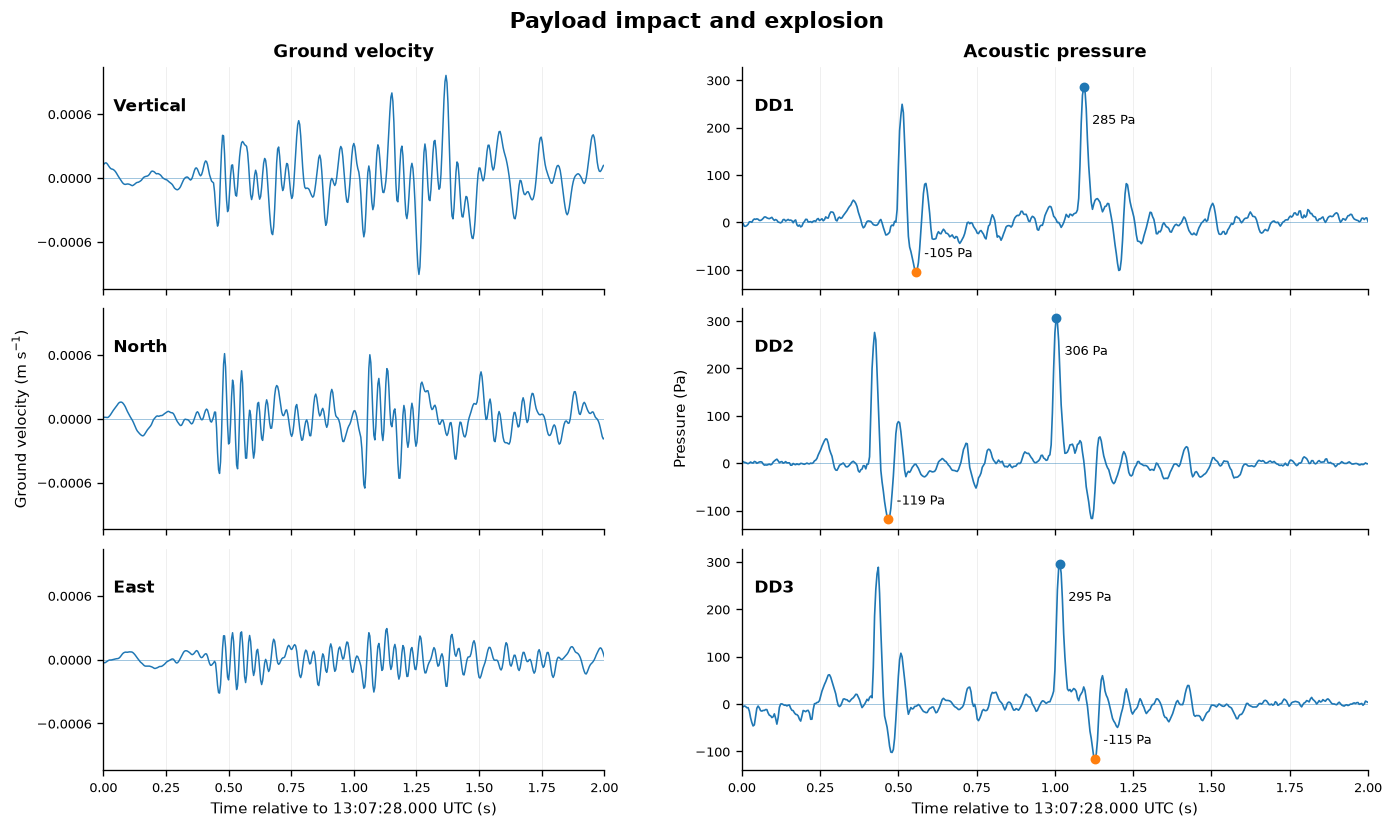

In [24]:
payload_window_rows = key_event_windows.loc[
    key_event_windows["event"]
    .astype(str)
    .str.contains("payload|capsule", case=False, regex=True, na=False)
].copy()

if payload_window_rows.empty:
    raise ValueError(
        "Notebook 080 exported no payload measurement windows"
    )

PAYLOAD_MEASUREMENT_START = UTCDateTime(
    str(payload_window_rows["window_start_utc"].min())
)
PAYLOAD_MEASUREMENT_END = UTCDateTime(
    str(payload_window_rows["window_end_utc"].max())
)
PAYLOAD_START = floor_utc_to_second(PAYLOAD_MEASUREMENT_START)
PAYLOAD_END = ceil_utc_to_second(PAYLOAD_MEASUREMENT_END)

st_payload = st_corr.copy().trim(
    PAYLOAD_START,
    PAYLOAD_END,
)
payload_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("payload|capsule", case=False, regex=True, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_payload,
    reference_time=PAYLOAD_START,
    pressure_results=payload_pressures,
    title="Payload impact and explosion",
    outfile=OUTDIR / "payload_explosion_waveforms.pdf",
)

## Named-event video-predicted versus observed arrival figure

This replaces the weak-shock timing sensitivity plot with a direct comparison for the three later named events. The initial upper-stage event is used only as the differential time reference. For each BCHH pressure channel, reviewed camera event intervals are added to that channel’s independently reviewed upper-stage arrival; those predicted arrivals are compared with the reviewed DD2/DD3 picks. Timing remains relative within each camera, so no absolute camera-clock synchronization is assumed. The payload rows assume an unchanged acoustic path; source motion or a change in source position can also affect the arrival-time residual.


In [30]:
def draw_camera_prediction(ax, interval, color, *, arrow_y):
    lo, hi = interval
    midpoint = (lo + hi) / 2

    ax.axvline(midpoint, color=color, lw=1.2, zorder=4)

    # Only draw an arrow when the camera timing is bracketed.
    if hi > lo:
        ax.annotate(
            "",
            xy=(hi, arrow_y),
            xytext=(lo, arrow_y),
            xycoords=ax.get_xaxis_transform(),
            arrowprops={
                "arrowstyle": "<->",
                "color": color,
                "lw": 1.3,
                "mutation_scale": 8,
                "shrinkA": 0,
                "shrinkB": 0,
            },
            annotation_clip=False,
        )

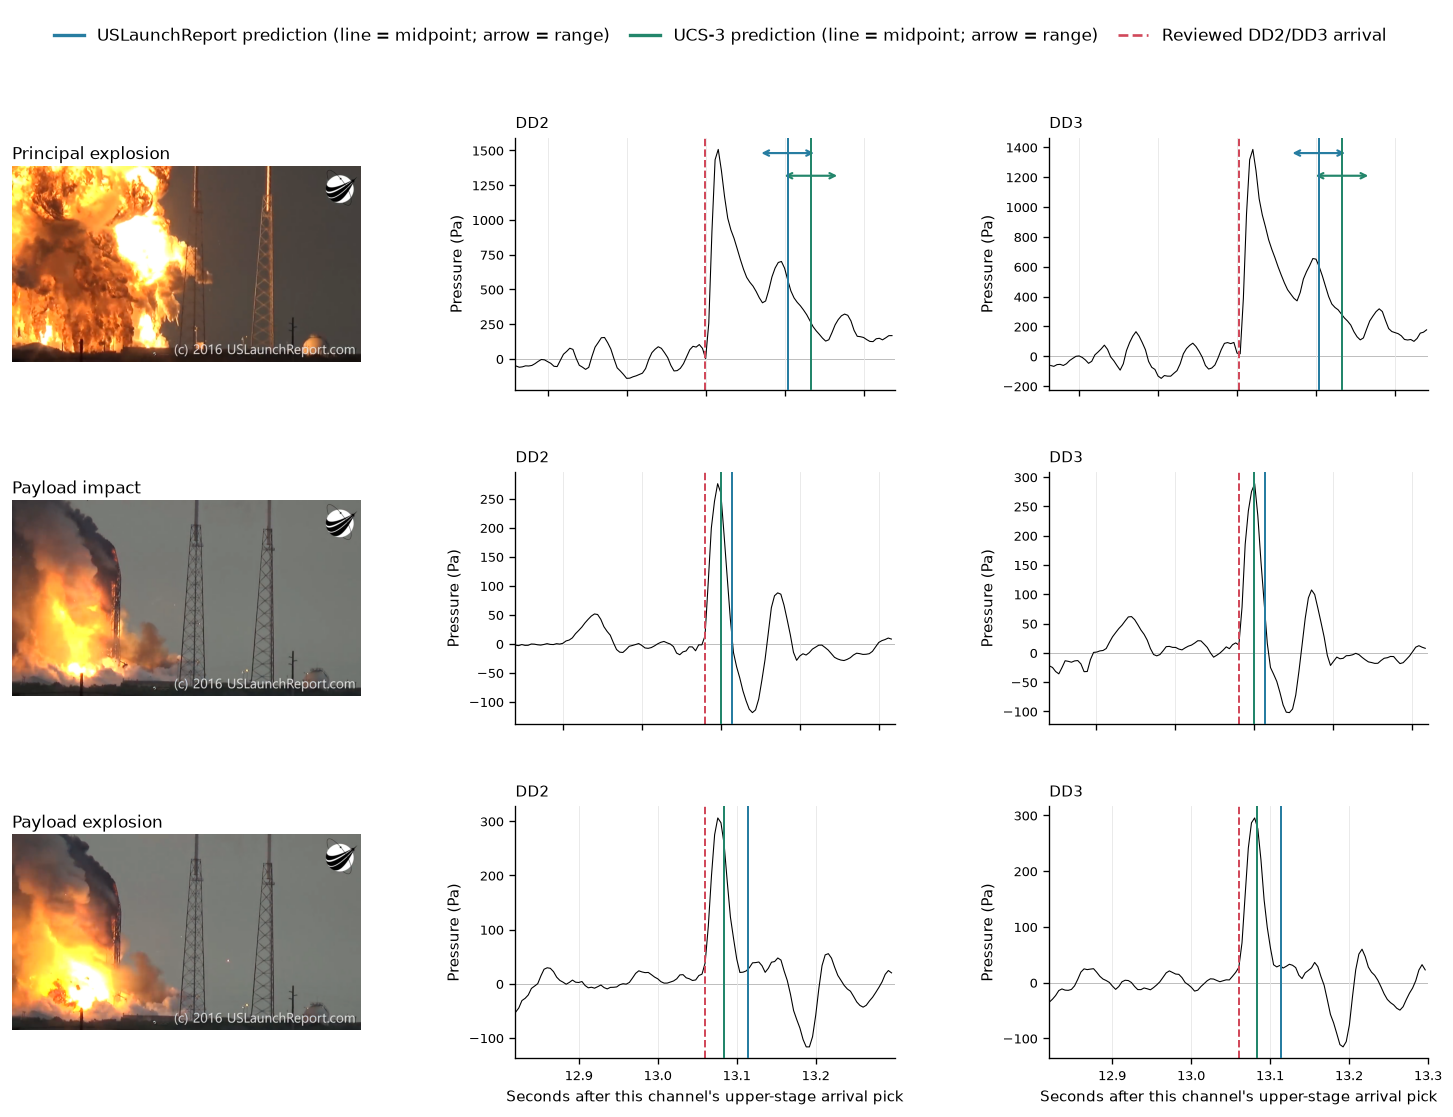

Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/fig_named_event_video_predicted_vs_observed_arrivals.pdf
Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/fig_named_event_video_predicted_vs_observed_arrivals.png


,event_key,event_label,camera,predicted_interval_start_s,predicted_interval_end_s,observed_DD2_interval_s,observed_DD3_interval_s,observed_median_interval_s,predicted_minus_observed_start_s,predicted_minus_observed_end_s
0,lower_stage,Principal explosion,USLaunchReport,3.570600,3.637300,3.499301,3.502727,3.501014,0.069586,0.136286
1,lower_stage,Principal explosion,UCS-3,3.600000,3.666667,3.499301,3.502727,3.501014,0.098986,0.165653
2,payload_impact,Payload impact,USLaunchReport,12.513800,12.513800,12.480061,12.480403,12.480232,0.033568,0.033568
3,payload_impact,Payload impact,UCS-3,12.500000,12.500000,12.480061,12.480403,12.480232,0.019768,0.019768
4,payload_explosion,Payload explosion,USLaunchReport,13.114400,13.114400,13.059889,13.060451,13.060170,0.054230,0.054230
5,payload_explosion,Payload explosion,UCS-3,13.083333,13.083333,13.059889,13.060451,13.060170,0.023163,0.023163


Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/named_event_timing_frame_audit.csv
Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/named_event_timing_residuals.csv


In [34]:
try:
    import av
except ImportError:
    av = None

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Reviewed timing values transcribed from the camera and receiver tables in the
# current supplement. Each camera's intervals are computed within that camera.
# The initial upper-stage event is used only as the zero-time reference.
NAMED_EVENT_DIFFERENTIAL_TIMING = {
    "lower_stage": {
        "label": "Principal explosion",
        "public_interval_s": (3.5706, 3.6373),
        "ucs3_interval_s": (3.6000, 3.666667),
        "arrival_interval_s": {
            "DD2": (3.499301, 3.499301),
            "DD3": (3.502727, 3.502727),
        },
        "frame_pts_s": 75.4048,
        "window_half_width_s": 0.24,
    },
    "payload_impact": {
        "label": "Payload impact",
        "public_interval_s": (12.5138, 12.5138),
        "ucs3_interval_s": (12.5000, 12.5000),
        "arrival_interval_s": {
            "DD2": (12.480061, 12.480061),
            "DD3": (12.480403, 12.480403),
        },
        "frame_pts_s": 84.2813,
        "window_half_width_s": 0.24,
    },
    "payload_explosion": {
        "label": "Payload explosion",
        "public_interval_s": (13.1144, 13.1144),
        "ucs3_interval_s": (13.083333, 13.083333),
        "arrival_interval_s": {
            "DD2": (13.059889, 13.059889),
            "DD3": (13.060451, 13.060451),
        },
        "frame_pts_s": 84.8819,
        "window_half_width_s": 0.24,
    },
}

NAMED_EVENT_TIMING_FIGURE = (
    OUTDIR / "fig_named_event_video_predicted_vs_observed_arrivals"
)
PUBLIC_INITIAL_PICK_PTS_S = 71.7675
BCHH_INITIAL_PICK_UTC = {
    "DD2": UTCDateTime("2016-09-01T13:07:15.927934"),
    "DD3": UTCDateTime("2016-09-01T13:07:15.935523"),
}


def differential_pressure_window(channel, center_s, half_width_s):
    """Extract baseline-corrected pressure against that channel's first pick."""
    matches = st_corr.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(matches)}")

    trace = matches[0]
    relative_s = trace.times(reftime=BCHH_INITIAL_PICK_UTC[channel])
    keep = np.abs(relative_s - center_s) <= half_width_s

    if not np.any(keep):
        raise ValueError(
            f"No {channel} samples near differential time {center_s:.3f} s"
        )

    return relative_s[keep], np.asarray(trace.data, dtype=float)[keep]


video_value = video_sync.get("video_file")
NAMED_EVENT_VIDEO_FILE = (
    Path(video_value).expanduser()
    if video_value
    else (
        Path(config.USLAUNCHREPORT_VIDEO_FILE)
        if config.USLAUNCHREPORT_VIDEO_FILE is not None
        else Path()
    )
)


def reviewed_video_frame(container, stream, requested_pts_s):
    """Decode the frame nearest a reviewed native movie presentation time."""
    seek_pts = int(max(0.0, requested_pts_s) / float(stream.time_base))
    container.seek(
        max(0, seek_pts),
        stream=stream,
        backward=True,
        any_frame=False,
    )

    best_frame = None
    best_pts_s = np.nan
    best_error_s = np.inf

    for frame in container.decode(stream):
        if frame.pts is None:
            continue

        pts_s = float(frame.pts * frame.time_base)
        error_s = abs(pts_s - requested_pts_s)

        if error_s < best_error_s:
            best_frame = frame
            best_pts_s = pts_s
            best_error_s = error_s

        if pts_s >= requested_pts_s:
            break

    if best_frame is None:
        raise RuntimeError(
            f"Could not decode a frame near PTS {requested_pts_s:.4f} s"
        )

    return best_frame.to_ndarray(format="rgb24"), best_pts_s


if av is None:
    warnings.warn("PyAV is unavailable; skipping the video-arrival figure.")

elif not NAMED_EVENT_VIDEO_FILE.is_file():
    warnings.warn(
        "The reviewed USLaunchReport video is unavailable; "
        f"skipping this figure: {NAMED_EVENT_VIDEO_FILE}"
    )

else:
    fig = plt.figure(figsize=(12.0, 9.2), constrained_layout=True)
    grid = fig.add_gridspec(
        4,
        3,
        height_ratios=(0.20, 1, 1, 1),
        width_ratios=(0.92, 1.0, 1.0),
        hspace=0.20,
        wspace=0.18,
    )

    # Reserve the first grid row for the legend so it cannot overlap the plots.
    legend_ax = fig.add_subplot(grid[0, :])
    legend_ax.axis("off")

    frame_audit_rows = []

    with av.open(str(NAMED_EVENT_VIDEO_FILE)) as container:
        video_stream = container.streams.video[0]
        video_stream.thread_type = "AUTO"

        for row_index, (event_key, event) in enumerate(
            NAMED_EVENT_DIFFERENTIAL_TIMING.items()
        ):
            plot_row = row_index + 1

            image_ax = fig.add_subplot(grid[plot_row, 0])
            image, actual_pts_s = reviewed_video_frame(
                container,
                video_stream,
                event["frame_pts_s"],
            )

            image_ax.imshow(image)
            image_ax.set_axis_off()
            image_ax.set_title(
                event["label"],
                fontsize=10,
                loc="left",
                pad=4,
            )

            frame_audit_rows.append({
                "event_key": event_key,
                "event_label": event["label"],
                "requested_frame_pts_s": event["frame_pts_s"],
                "decoded_frame_pts_s": actual_pts_s,
                "frame_offset_from_initial_public_pick_s": (
                    actual_pts_s - PUBLIC_INITIAL_PICK_PTS_S
                ),
            })

            for col_index, channel in enumerate(("DD2", "DD3"), start=1):
                ax = fig.add_subplot(grid[plot_row, col_index])

                observed_interval = event["arrival_interval_s"][channel]
                observed_s = float(np.mean(observed_interval))
                half_width_s = event["window_half_width_s"]

                x_s, pressure_pa = differential_pressure_window(
                    channel,
                    observed_s,
                    half_width_s,
                )

                ax.plot(
                    x_s,
                    pressure_pa,
                    color="black",
                    lw=0.65,
                    rasterized=True,
                )
                ax.axhline(0.0, color="0.75", lw=0.6, zorder=0)

                public_lo, public_hi = event["public_interval_s"]
                ucs3_lo, ucs3_hi = event["ucs3_interval_s"]

                if public_hi > public_lo:
                    #ax.axvspan(
                    #    public_lo,
                    #    public_hi,
                    #    color="#277DA1",
                    #    alpha=0.18,
                    #    lw=0,
                    #)
                    ax.axvline(
                        (public_lo + public_hi) / 2,
                        color="#277DA1",
                        lw=1.1,
                    )
                else:
                    ax.axvline(public_lo, color="#277DA1", lw=1.2)

                if ucs3_hi > ucs3_lo:
                    #ax.axvspan(
                    #    ucs3_lo,
                    #    ucs3_hi,
                    #    color="#43AA8B",
                    #    alpha=0.20,
                    #    lw=0,
                    #)
                    ax.axvline(
                        (ucs3_lo + ucs3_hi) / 2,
                        color="#23866B",
                        lw=1.1,
                    )
                else:
                    ax.axvline(ucs3_lo, color="#23866B", lw=1.2)

                ax.axvline(
                    observed_s,
                    color="#D1495B",
                    ls="--",
                    lw=1.2,
                )

                draw_camera_prediction(
                    ax, event["public_interval_s"], "#277DA1", arrow_y=0.94
                )
                draw_camera_prediction(
                    ax, event["ucs3_interval_s"], "#23866B", arrow_y=0.85
                )

                ax.set_xlim(
                    observed_s - half_width_s,
                    observed_s + half_width_s,
                )
                ax.set_ylabel("Pressure (Pa)")
                ax.set_title(channel, fontsize=9, loc="left")
                ax.grid(axis="x", color="0.90", lw=0.5)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)

                if row_index == 2:
                    ax.set_xlabel(
                        "Seconds after this channel's upper-stage arrival pick"
                    )
                else:
                    ax.tick_params(labelbottom=False)
    legend_ax.legend(
        handles=[
            Line2D(
                [0], [0],
                color="#277DA1",
                lw=2,
                label="USLaunchReport prediction (line = midpoint; arrow = range)",
            ),
            Line2D(
                [0], [0],
                color="#23866B",
                lw=2,
                label="UCS-3 prediction (line = midpoint; arrow = range)",
            ),
            Line2D(
                [0], [0],
                color="#D1495B",
                ls="--",
                lw=1.6,
                label="Reviewed DD2/DD3 arrival",
            ),
        ],
        loc="center",
        ncol=3,
        fontsize=10,
        handlelength=1.8,
        columnspacing=1.2,
        frameon=False,
    )

    fig.savefig(
        NAMED_EVENT_TIMING_FIGURE.with_suffix(".pdf"),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    fig.savefig(
        NAMED_EVENT_TIMING_FIGURE.with_suffix(".png"),
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.05,
    )
    plt.show()

    print("Wrote:", NAMED_EVENT_TIMING_FIGURE.with_suffix(".pdf"))
    print("Wrote:", NAMED_EVENT_TIMING_FIGURE.with_suffix(".png"))

    frame_audit = pd.DataFrame(frame_audit_rows)
    frame_audit_file = OUTDIR / "named_event_timing_frame_audit.csv"
    frame_audit.to_csv(frame_audit_file, index=False)

    residual_rows = []
    for event_key, event in NAMED_EVENT_DIFFERENTIAL_TIMING.items():
        observed_median_s = float(np.median([
            event["arrival_interval_s"]["DD2"][0],
            event["arrival_interval_s"]["DD3"][0],
        ]))

        for camera, key in (
            ("USLaunchReport", "public_interval_s"),
            ("UCS-3", "ucs3_interval_s"),
        ):
            predicted_start_s, predicted_end_s = event[key]

            residual_rows.append({
                "event_key": event_key,
                "event_label": event["label"],
                "camera": camera,
                "predicted_interval_start_s": predicted_start_s,
                "predicted_interval_end_s": predicted_end_s,
                "observed_DD2_interval_s": (
                    event["arrival_interval_s"]["DD2"][0]
                ),
                "observed_DD3_interval_s": (
                    event["arrival_interval_s"]["DD3"][0]
                ),
                "observed_median_interval_s": observed_median_s,
                "predicted_minus_observed_start_s": (
                    predicted_start_s - observed_median_s
                ),
                "predicted_minus_observed_end_s": (
                    predicted_end_s - observed_median_s
                ),
            })

    residual_table = pd.DataFrame(residual_rows)
    residual_file = OUTDIR / "named_event_timing_residuals.csv"
    residual_table.to_csv(residual_file, index=False)
    display(residual_table)

    print("Wrote:", frame_audit_file)
    print("Wrote:", residual_file)

## Regional detectability: supplementary publication products

Import the station coverage map, screening summary, northern-corridor record section,
selected candidate waveforms, timing comparison and station audit from `config.NB120_DIR`.
The analysis remains in Notebook 120. Copies, captions and a provenance manifest are
written to `config.NB140_DIR / "regional_detectability"`.

These products document screening and exploratory associations, not confirmed regional
detections or a regional null result. No regional yield estimates are included.
The effective band can differ by channel (in particular for low-rate LDO records).

The user previously reviewed candidate windows. The current review CSV may not retain
those decisions. Its saved classifications are reported without assuming that the earlier
review did not occur. Reconcile any earlier review against the current window identities
and processing before repeating review; a change from 93 to 94 candidates does not imply
that exactly one new window was added. This section never changes the upstream review files.


In [26]:
# Publish existing Notebook 120 products without rerunning its scientific analysis.
import shutil
from datetime import datetime, timezone

REGIONAL_SOURCE_DIR = config.NB120_DIR
REGIONAL_PUBLICATION_DIR = OUTDIR / "regional_detectability"
REGIONAL_PUBLICATION_DIR.mkdir(parents=True, exist_ok=True)

regional_products = {
    "supplement_regional_station_map.pdf": "Station coverage. Automatic candidates are screening flags, not confirmed detections; unavailable data are not non-detections.",
    "regional_detectability_screening_summary.pdf": "Regional screening summary. Counts describe the automated search, not reviewed detections.",
    "145_northern_corridor_source_reduced_section.pdf": "All screened infrasound stations within 30 degrees of north, independently normalized. Reduced time uses an exploratory slow branch and a model-derived source-time reference.",
    "145_focused_candidate_raw_and_pressure_audit.pdf": "Selected candidate waveforms at IU.DWPF, N4.257A, N4.S54A and N4.R55A. Selection was post hoc; single-station transients do not establish association.",
    "145_focused_candidate_moveout_test.pdf": "Exploratory timing comparison of selected peaks. The source-time reference is derived from local acoustic reduction; fitted celerity does not identify an atmospheric path.",
    "supplement_regional_station_audit.csv": "Station audit with availability, effective bands and screening metrics. Pair with the phase-level manual-review tables below.",
    "regional_candidate_manual_review.csv": "Read-only publication snapshot of current candidate classifications; edit the authoritative Notebook 120 file, not this copy.",
    "regional_phase_manual_review.csv": "Read-only publication snapshot of all phase-window classifications.",
    "145_focused_regional_candidate_metrics.csv": "Metrics supporting selected candidate waveforms.",
    "145_posthoc_slow_branch_timing.csv": "Timing diagnostics for the post-hoc selected slow branch.",
    "regional_detectability_run_metadata.json": "Notebook 120 screening parameters and timing provenance.",
}
regional_records = []
for filename, caption in regional_products.items():
    source = REGIONAL_SOURCE_DIR / filename
    destination = REGIONAL_PUBLICATION_DIR / filename
    record = {"filename": filename, "source": str(source), "caption_or_note": caption}
    if source.is_file():
        shutil.copy2(source, destination)
        record.update(status="copied", destination=str(destination), **file_fingerprint(source))
    else:
        # Do not leave an older publication copy looking like a current product.
        if destination.exists():
            archive = REGIONAL_PUBLICATION_DIR / "previous_exports"
            archive.mkdir(exist_ok=True)
            stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
            destination.replace(archive / f"{stamp}_{filename}")
        record["status"] = "missing"
        warnings.warn(f"Regional publication product unavailable: {source}; run/check Notebook 120.")
    regional_records.append(record)

review_path = REGIONAL_SOURCE_DIR / "regional_candidate_manual_review.csv"
regional_review_summary = {"status": "review_file_unavailable"}
if review_path.is_file():
    # Preserve empty SEED location codes and original manual text in copied files.
    regional_review = pd.read_csv(review_path, dtype=str, keep_default_na=False)
    if "manual_classification" in regional_review:
        classifications = regional_review["manual_classification"].str.strip().str.lower().replace("", "not_reviewed")
        regional_review_summary = {
            "candidate_windows_in_current_file": len(regional_review),
            "recorded_classifications": classifications.value_counts().to_dict(),
            "interpretation": (
                "These counts describe the current saved review file only. They do not establish "
                "whether an earlier version was reviewed. A change in candidate count alone "
                "cannot identify added, removed or changed windows."
            ),
        }
        if classifications.eq("not_reviewed").any():
            warnings.warn(
                "The current Notebook 120 file contains windows without a recorded classification. "
                "Earlier review may exist elsewhere; reconcile by station/channel, phase and window "
                "times before making detection or non-detection claims."
            )
    else:
        regional_review_summary = {"status": "manual_classification_column_missing"}

regional_manifest = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "source_directory": str(REGIONAL_SOURCE_DIR),
    "products": regional_records,
    "review_summary": regional_review_summary,
    "publication_scope": "Supplementary screening evidence; no regional yield estimates or automatic confirmation of detections.",
}
(REGIONAL_PUBLICATION_DIR / "regional_publication_manifest.json").write_text(
    json.dumps(regional_manifest, indent=2) + "\n", encoding="utf-8"
)
regional_notes = [
    "# Regional detectability publication products", "",
    "These are copies of Notebook 120 outputs; no screening or propagation fits were rerun.",
    "Use the manifest to identify products available in this export and their source fingerprints.",
    "Manual review is recorded in Notebook 120. Publication copies must not be used as the editable review master.",
    "Current saved classifications do not invalidate a review performed on an earlier version.",
    "To reconcile an earlier review, compare sensor type, network, station, location, channel, phase,",
    "window start/end, peak time and processing settings. Carry decisions forward only for unchanged windows.",
    "The candidate count alone cannot identify which windows need new review.", "",
    "## Figure captions and table notes", "",
]
for record in regional_records:
    regional_notes.append(f"- {record['filename']} [{record['status']}]: {record['caption_or_note']}")
regional_notes.extend(["", "## Current saved review status", "", json.dumps(regional_review_summary, indent=2)])
(REGIONAL_PUBLICATION_DIR / "README.md").write_text("\n".join(regional_notes) + "\n", encoding="utf-8")
display(pd.DataFrame(regional_records)[["filename", "status", "caption_or_note"]])
pprint(regional_review_summary)
print("Regional supplementary products:", REGIONAL_PUBLICATION_DIR)


/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_5651/483917198.py:58: UserWarning: The current Notebook 120 file contains windows without a recorded classification. Earlier review may exist elsewhere; reconcile by station/channel, phase and window times before making detection or non-detection claims.
  warnings.warn(


,filename,status,caption_or_note
0,supplement_regional_station_map.pdf,copied,Station coverage. Automatic candidates are scr...
1,regional_detectability_screening_summary.pdf,copied,Regional screening summary. Counts describe th...
2,145_northern_corridor_source_reduced_section.pdf,copied,All screened infrasound stations within 30 deg...
3,145_focused_candidate_raw_and_pressure_audit.pdf,copied,"Selected candidate waveforms at IU.DWPF, N4.25..."
4,145_focused_candidate_moveout_test.pdf,copied,Exploratory timing comparison of selected peak...
5,supplement_regional_station_audit.csv,copied,"Station audit with availability, effective ban..."
6,regional_candidate_manual_review.csv,copied,Read-only publication snapshot of current cand...
7,regional_phase_manual_review.csv,copied,Read-only publication snapshot of all phase-wi...
8,145_focused_regional_candidate_metrics.csv,copied,Metrics supporting selected candidate waveforms.
9,145_posthoc_slow_branch_timing.csv,copied,Timing diagnostics for the post-hoc selected s...


{'candidate_windows_in_current_file': 94,
 'interpretation': 'These counts describe the current saved review file only. '
                   'They do not establish whether an earlier version was '
                   'reviewed. A change in candidate count alone cannot '
                   'identify added, removed or changed windows.',
 'recorded_classifications': {'not_reviewed': 94}}
Regional supplementary products: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/140_generate_publication_figures/regional_detectability
